In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load all datasets
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

In [5]:
# Quick overview function
def quick_overview(df, name):
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nData Types:\n{df.dtypes}")
    print(f"\nMissing Values:\n{df.isnull().sum()}")
    print(f"\nFirst 3 rows:\n{df.head(3)}")
    print(f"{'='*50}\n")

# Run overview on all datasets
quick_overview(customers, 'Customers')
quick_overview(orders, 'Orders')
quick_overview(order_items, 'Order Items')
quick_overview(order_payments, 'Order Payments')
quick_overview(order_reviews, 'Order Reviews')
quick_overview(products, 'Products')
quick_overview(sellers, 'Sellers')
quick_overview(geolocation, 'Geolocation')
quick_overview(category_translation, 'Category Translation')

Dataset: Customers
Shape: 99441 rows x 5 columns

Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

First 3 rows:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1             

In [7]:
# ORDERS CLEANING 
# Convert all date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Check order status breakdown
print("Order Status Breakdown:")
print(orders['order_status'].value_counts())
print(f"\nMissing values after cleaning:\n{orders.isnull().sum()}")
print(f"\nData types:\n{orders.dtypes}")

Order Status Breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Missing values after cleaning:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Data types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [9]:
# ORDERS FEATURE ENGINEERING

# Extract date parts from purchase timestamp
orders['purchase_year']    = orders['order_purchase_timestamp'].dt.year
orders['purchase_month']   = orders['order_purchase_timestamp'].dt.month
orders['purchase_day']     = orders['order_purchase_timestamp'].dt.day
orders['purchase_dayofweek'] = orders['order_purchase_timestamp'].dt.dayofweek  # 0=Monday
orders['purchase_hour']    = orders['order_purchase_timestamp'].dt.hour

# Calculate delivery time in days (actual)
orders['delivery_days_actual'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_purchase_timestamp']
).dt.days

# Calculate estimated delivery time in days
orders['delivery_days_estimated'] = (
    orders['order_estimated_delivery_date'] - 
    orders['order_purchase_timestamp']
).dt.days

# Was order delivered early or late? (negative = early, positive = late)
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_estimated_delivery_date']
).dt.days

# Flag late deliveries
orders['is_late'] = orders['delivery_delay_days'] > 0

print(f"\nNew columns added:\n{orders.columns.tolist()}")
print(f"\nSample delivery stats:")
print(orders[['delivery_days_actual','delivery_days_estimated','delivery_delay_days','is_late']].describe())


New columns added:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'delivery_days_actual', 'delivery_days_estimated', 'delivery_delay_days', 'is_late']

Sample delivery stats:
       delivery_days_actual  delivery_days_estimated  delivery_delay_days
count          96476.000000             99441.000000         96476.000000
mean              12.094086                23.403958           -11.876881
std                9.551746                 8.829562            10.183854
min                0.000000                 1.000000          -147.000000
25%                6.000000                18.000000           -17.000000
50%               10.000000                23.000000           -12.000000
75%               15.000000                28.000000            -7.00000

In [11]:
# PRODUCTS CLEANING 

# Fill missing category names with 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Fill missing dimensions with median
dim_cols = ['product_name_lenght', 'product_description_lenght', 
            'product_photos_qty', 'product_weight_g', 
            'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in dim_cols:
    products[col] = products[col].fillna(products[col].median())

# Merge with English category names
products = products.merge(category_translation, on='product_category_name', how='left')

# Fill any remaining untranslated categories
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

print("Products cleaned")
print(f"Missing values:\n{products.isnull().sum()}")
print(f"\nSample:\n{products[['product_id','product_category_name','product_category_name_english']].head()}")

Products cleaned
Missing values:
product_id                       0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64

Sample:
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

  product_category_name_english  
0                     perfumery  
1                           art  
2                sports_leisure  
3                          baby  
4                    housewares  


In [13]:
# ORDER REVIEWS CLEANING 

# Fill missing comment fields with 'no comment'
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].fillna('no comment')
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna('no comment')

# Convert dates to datetime
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

print("Order Reviews cleaned")
print(f"Missing values:\n{order_reviews.isnull().sum()}")

Order Reviews cleaned
Missing values:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [15]:
# ORDER ITEMS CLEANING 

# Convert shipping date to datetime
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Create total item value column
order_items['total_item_value'] = order_items['price'] + order_items['freight_value']

print("Order Items cleaned")
print(f"Missing values:\n{order_items.isnull().sum()}")
print(f"\nSample stats:\n{order_items[['price','freight_value','total_item_value']].describe()}")

Order Items cleaned
Missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
total_item_value       0
dtype: int64

Sample stats:
               price  freight_value  total_item_value
count  112650.000000  112650.000000     112650.000000
mean      120.653739      19.990320        140.644059
std       183.633928      15.806405        190.724394
min         0.850000       0.000000          6.080000
25%        39.900000      13.080000         55.220000
50%        74.990000      16.260000         92.320000
75%       134.900000      21.150000        157.937500
max      6735.000000     409.680000       6929.310000


In [17]:
# CUSTOMERS CLEANING 

# Standardise city names to title case
customers['customer_city'] = customers['customer_city'].str.title()
customers['customer_state'] = customers['customer_state'].str.upper()

print("Customers cleaned")
print(f"Missing values:\n{customers.isnull().sum()}")
print(f"\nTop 5 cities:\n{customers['customer_city'].value_counts().head()}")

Customers cleaned
Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Top 5 cities:
customer_city
Sao Paulo         15540
Rio De Janeiro     6882
Belo Horizonte     2773
Brasilia           2131
Curitiba           1521
Name: count, dtype: int64


In [19]:
# EXPORT CLEANED DATASETS 

orders.to_csv('cleaned_orders.csv', index=False)
customers.to_csv('cleaned_customers.csv', index=False)
order_items.to_csv('cleaned_order_items.csv', index=False)
order_payments.to_csv('cleaned_order_payments.csv', index=False)
order_reviews.to_csv('cleaned_order_reviews.csv', index=False)
products.to_csv('cleaned_products.csv', index=False)
sellers.to_csv('cleaned_sellers.csv', index=False)
geolocation.to_csv('cleaned_geolocation.csv', index=False)



In [18]:
#  SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)

In [21]:
# Plot style settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

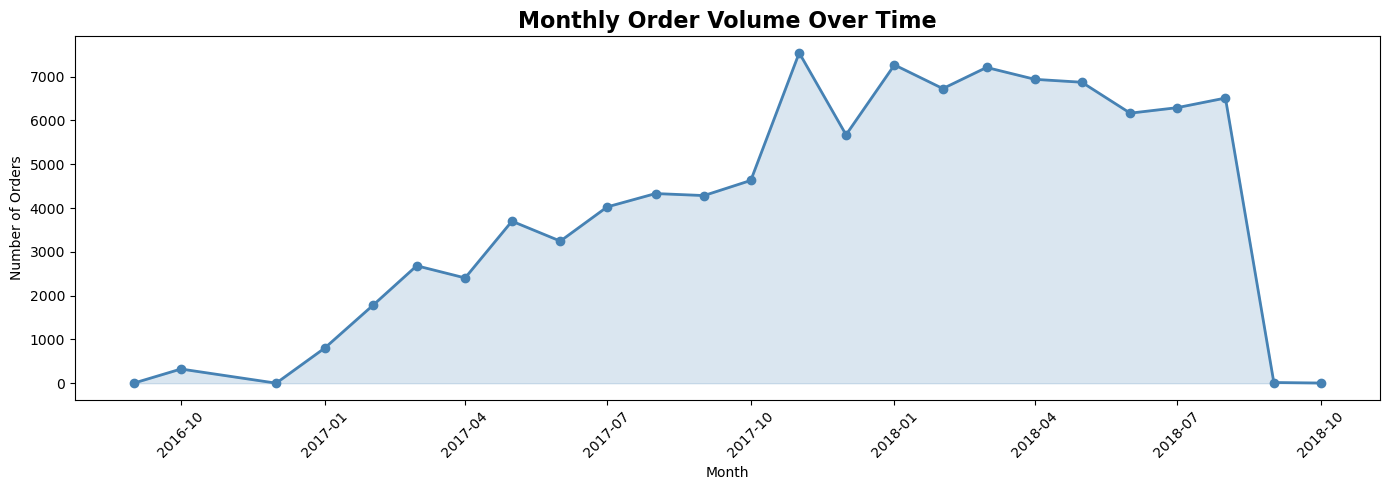

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Peak month: November 2017
Peak orders: 7544


In [21]:
# EDA 1: Orders Over Time 
# Group orders by month to see business growth trend
orders['purchase_yearmonth'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders_over_time = orders.groupby('purchase_yearmonth').size().reset_index(name='order_count')
orders_over_time['purchase_yearmonth'] = orders_over_time['purchase_yearmonth'].dt.to_timestamp()

# Line chart with shaded area to show growth trend
plt.figure(figsize=(14, 5))
plt.plot(orders_over_time['purchase_yearmonth'], orders_over_time['order_count'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(orders_over_time['purchase_yearmonth'],
                 orders_over_time['order_count'], alpha=0.2, color='steelblue')
plt.title('Monthly Order Volume Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Date range: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")
print(f"Peak month: {orders_over_time.loc[orders_over_time['order_count'].idxmax(), 'purchase_yearmonth'].strftime('%B %Y')}")
print(f"Peak orders: {orders_over_time['order_count'].max()}")

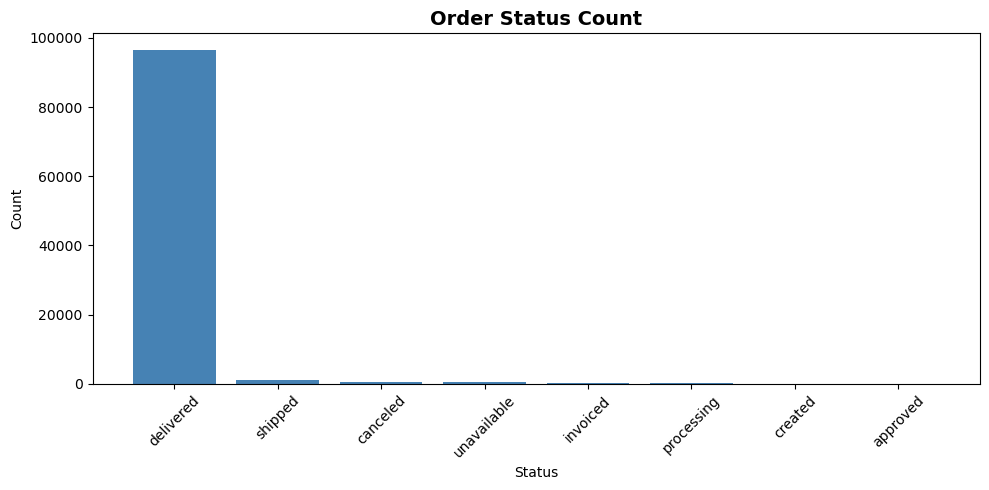

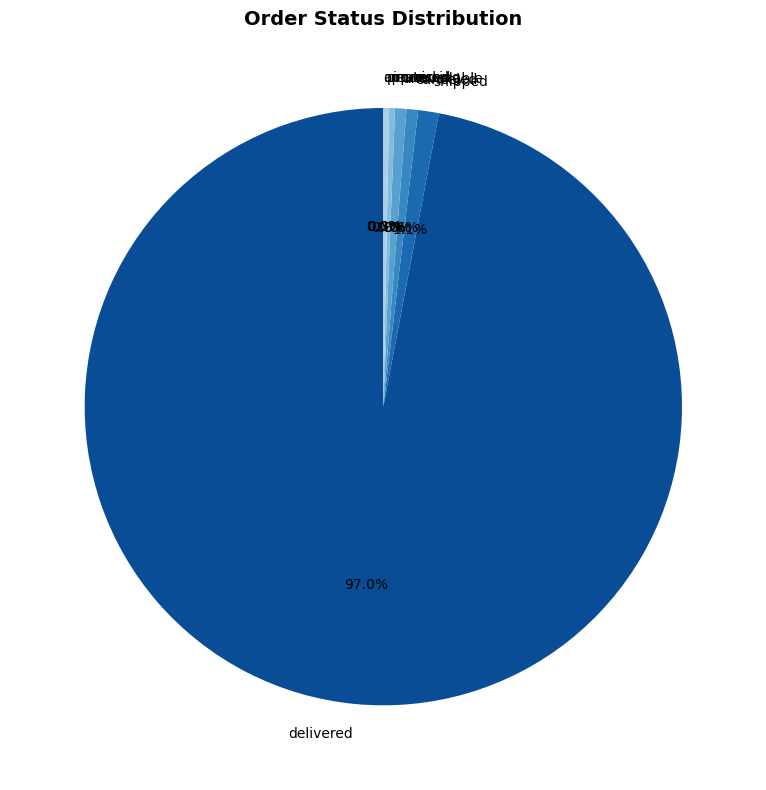

order_status  count  percentage
   delivered  96478       97.02
     shipped   1107        1.11
    canceled    625        0.63
 unavailable    609        0.61
    invoiced    314        0.32
  processing    301        0.30
     created      5        0.01
    approved      2        0.00


In [23]:
# EDA 2: Order Status Breakdown 
# Count orders by status to understand order pipeline
status_counts = orders['order_status'].value_counts().reset_index()
status_counts.columns = ['order_status', 'count']
status_counts['percentage'] = (status_counts['count'] / len(orders) * 100).round(2)

# Bar chart showing count per status
plt.figure(figsize=(10, 5))
plt.bar(status_counts['order_status'], status_counts['count'], color='steelblue')
plt.title('Order Status Count', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart showing percentage distribution
plt.figure(figsize=(8, 8))
plt.pie(status_counts['count'], labels=status_counts['order_status'],
        autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('Blues_r', len(status_counts)))
plt.title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(status_counts.to_string(index=False))

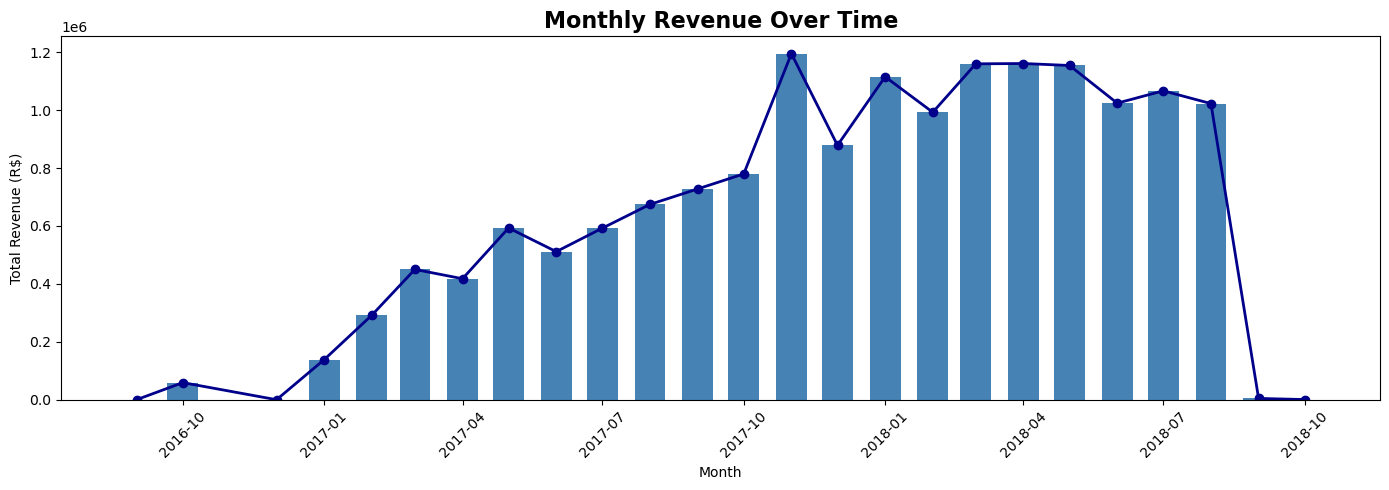

Total Revenue: R$16,008,872.12
Average Monthly Revenue: R$640,354.88
Peak Revenue Month: November 2017


In [24]:
# EDA 3: Revenue Over Time 
# Merge orders with payments to get revenue per month
order_revenue = orders[['order_id', 'purchase_yearmonth']].merge(
    order_payments[['order_id', 'payment_value']], on='order_id', how='left')

monthly_revenue = order_revenue.groupby('purchase_yearmonth')['payment_value'].sum().reset_index()
monthly_revenue['purchase_yearmonth'] = monthly_revenue['purchase_yearmonth'].dt.to_timestamp()

# Bar chart with line overlay to show revenue trend
plt.figure(figsize=(14, 5))
plt.bar(monthly_revenue['purchase_yearmonth'], monthly_revenue['payment_value'],
        color='steelblue', width=20)
plt.plot(monthly_revenue['purchase_yearmonth'], monthly_revenue['payment_value'],
         color='darkblue', linewidth=2, marker='o')
plt.title('Monthly Revenue Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total Revenue: R${order_revenue['payment_value'].sum():,.2f}")
print(f"Average Monthly Revenue: R${monthly_revenue['payment_value'].mean():,.2f}")
print(f"Peak Revenue Month: {monthly_revenue.loc[monthly_revenue['payment_value'].idxmax(), 'purchase_yearmonth'].strftime('%B %Y')}")

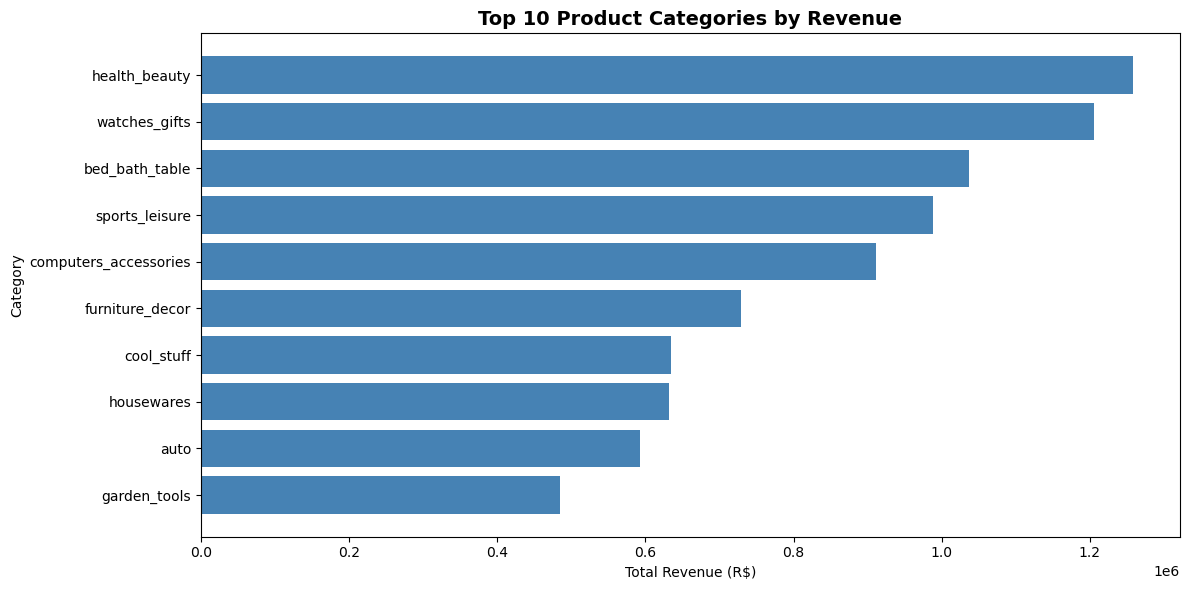

             category    revenue
        health_beauty 1258681.34
        watches_gifts 1205005.68
       bed_bath_table 1036988.68
       sports_leisure  988048.97
computers_accessories  911954.32
      furniture_decor  729762.49
           cool_stuff  635290.85
           housewares  632248.66
                 auto  592720.11
         garden_tools  485256.46


In [27]:
# EDA 4: Top Product Categories 
# Merge order items with product info to get category revenue
items_products = order_items.merge(
    products[['product_id', 'product_category_name_english']],
    on='product_id', how='left')

# Get top 10 categories by total revenue
category_revenue = items_products.groupby('product_category_name_english')['price'].sum()\
    .sort_values(ascending=False).head(10).reset_index()
category_revenue.columns = ['category', 'revenue']

# Horizontal bar chart — easier to read long category names
plt.figure(figsize=(12, 6))
plt.barh(category_revenue['category'], category_revenue['revenue'], color='steelblue')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Category')
plt.gca().invert_yaxis()  # Highest revenue at top
plt.tight_layout()
plt.show()

print(category_revenue.to_string(index=False))

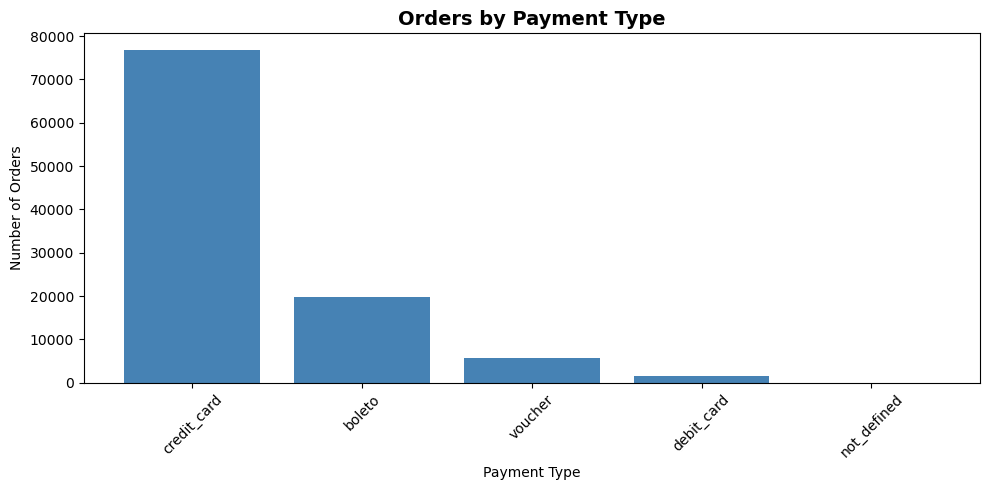

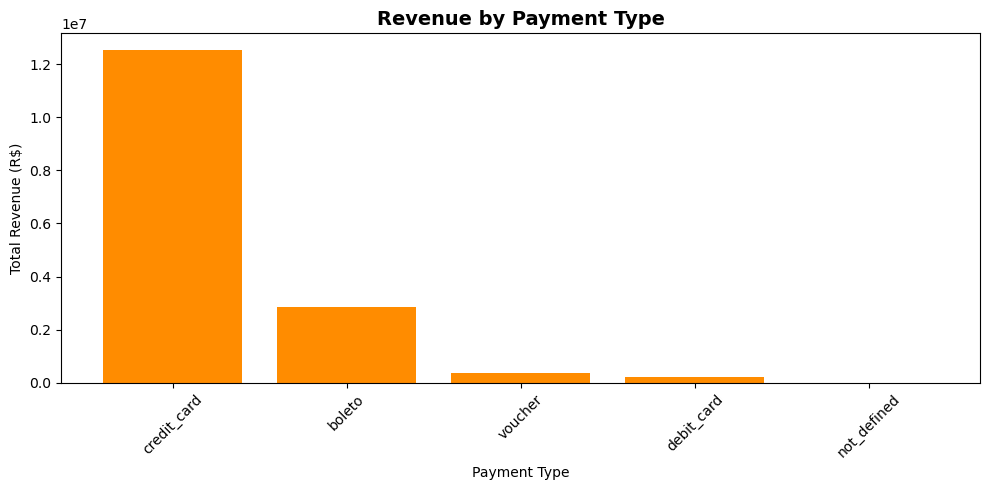

payment_type  order_count  total_value  avg_value
 credit_card        76795  12542084.19 163.319021
      boleto        19784   2869361.27 145.034435
     voucher         5775    379436.87  65.703354
  debit_card         1529    217989.79 142.570170
 not_defined            3         0.00   0.000000


In [29]:
# EDA 5: Payment Type Analysis 
# Aggregate payment data by type
payment_type = order_payments.groupby('payment_type').agg(
    order_count=('order_id', 'count'),
    total_value=('payment_value', 'sum'),
    avg_value=('payment_value', 'mean')
).reset_index().sort_values('order_count', ascending=False)

# Bar chart — number of orders per payment type
plt.figure(figsize=(10, 5))
plt.bar(payment_type['payment_type'], payment_type['order_count'], color='steelblue')
plt.title('Orders by Payment Type', fontsize=14, fontweight='bold')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar chart — total revenue per payment type
plt.figure(figsize=(10, 5))
plt.bar(payment_type['payment_type'], payment_type['total_value'], color='darkorange')
plt.title('Revenue by Payment Type', fontsize=14, fontweight='bold')
plt.xlabel('Payment Type')
plt.ylabel('Total Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(payment_type.to_string(index=False))

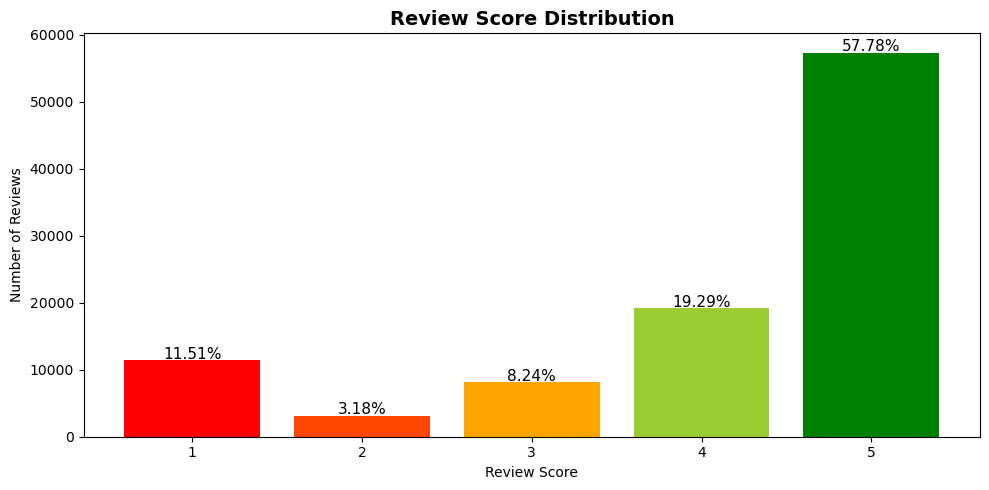

 score  count  percentage
     1  11424       11.51
     2   3151        3.18
     3   8179        8.24
     4  19142       19.29
     5  57328       57.78

Average Review Score: 4.09


In [31]:
# EDA 6: Review Score Distribution 
# Count reviews per score to understand customer satisfaction
review_dist = order_reviews['review_score'].value_counts().sort_index().reset_index()
review_dist.columns = ['score', 'count']
review_dist['percentage'] = (review_dist['count'] / len(order_reviews) * 100).round(2)

# Bar chart with percentage labels — colour coded by score
plt.figure(figsize=(10, 5))
bars = plt.bar(review_dist['score'], review_dist['count'],
               color=['red', 'orangered', 'orange', 'yellowgreen', 'green'])
plt.title('Review Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

# Add percentage label on top of each bar
for bar, pct in zip(bars, review_dist['percentage']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{pct}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(review_dist.to_string(index=False))
print(f"\nAverage Review Score: {order_reviews['review_score'].mean():.2f}")

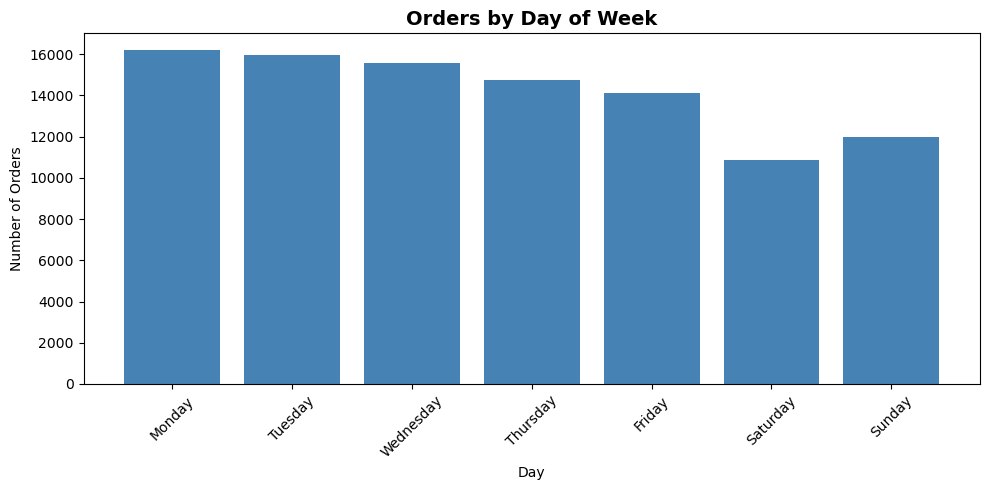

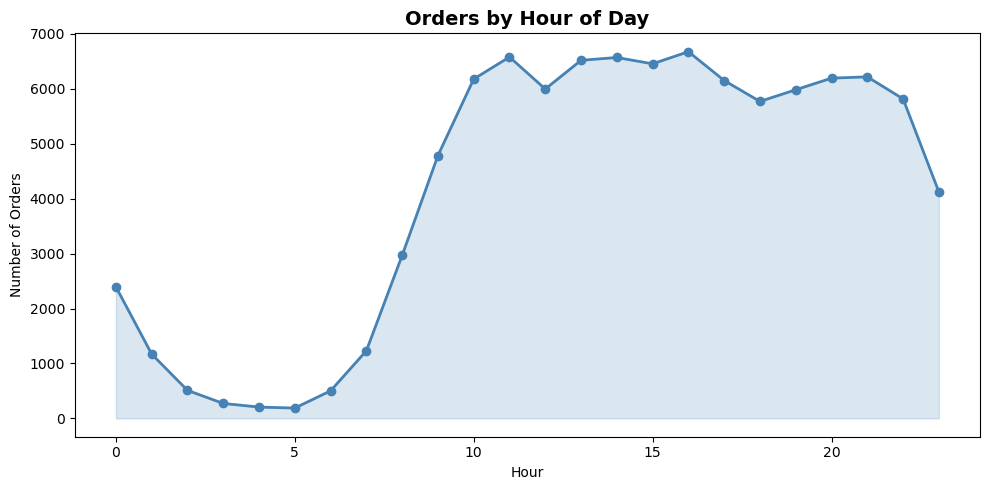

In [33]:
# EDA 7: Orders by Day of Week & Hour 
# Understand when customers shop most

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = orders.groupby('purchase_dayofweek').size().reset_index(name='count')
orders_by_day['day_name'] = orders_by_day['purchase_dayofweek'].map(dict(enumerate(day_labels)))

orders_by_hour = orders.groupby('purchase_hour').size().reset_index(name='count')

# Bar chart — orders by day of week
plt.figure(figsize=(10, 5))
plt.bar(orders_by_day['day_name'], orders_by_day['count'], color='steelblue')
plt.title('Orders by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Line chart — orders by hour of day
plt.figure(figsize=(10, 5))
plt.plot(orders_by_hour['purchase_hour'], orders_by_hour['count'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(orders_by_hour['purchase_hour'], orders_by_hour['count'],
                 alpha=0.2, color='steelblue')
plt.title('Orders by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

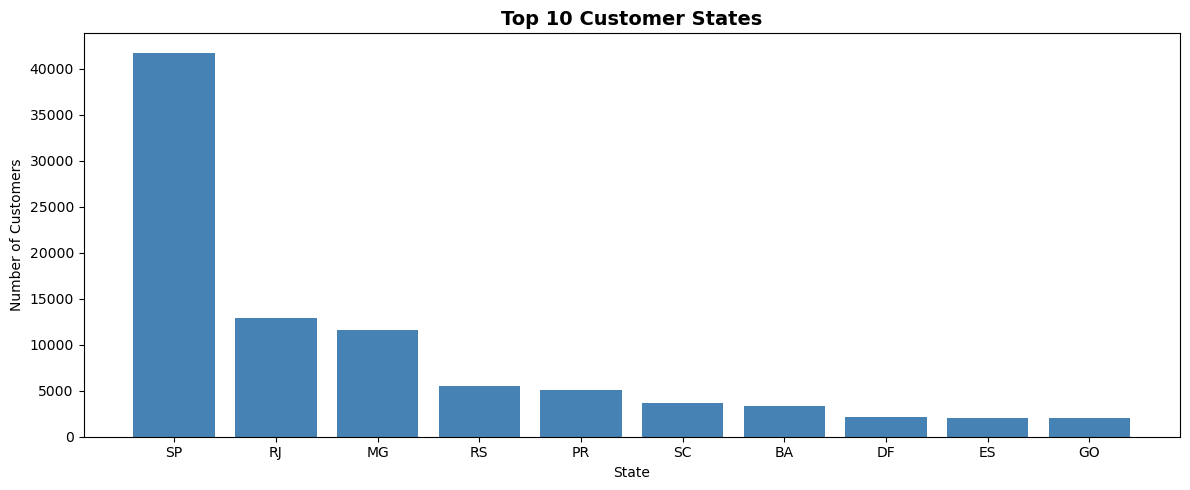

state  count  percentage
   SP  41746       41.98
   RJ  12852       12.92
   MG  11635       11.70
   RS   5466        5.50
   PR   5045        5.07
   SC   3637        3.66
   BA   3380        3.40
   DF   2140        2.15
   ES   2033        2.04
   GO   2020        2.03


In [35]:
# ── EDA 8: Top 10 Customer States ──────────────────────────────
# Identify which states have the most customers

top_states = customers['customer_state'].value_counts().head(10).reset_index()
top_states.columns = ['state', 'count']
top_states['percentage'] = (top_states['count'] / len(customers) * 100).round(2)

# Bar chart showing customer distribution by state
plt.figure(figsize=(12, 5))
plt.bar(top_states['state'], top_states['count'], color='steelblue')
plt.title('Top 10 Customer States', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(top_states.to_string(index=False))

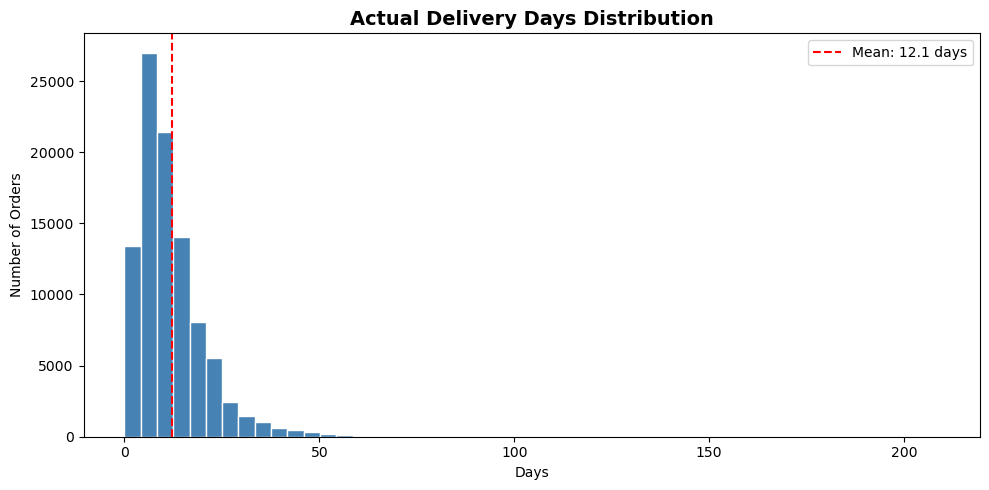

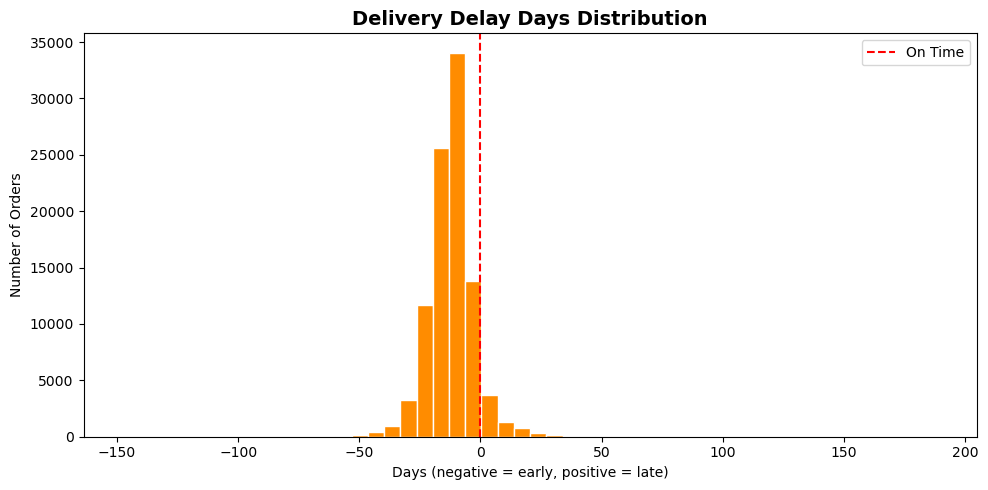

Total delivered orders: 96,478
On time / Early: 89,944 (93.2%)
Late orders: 6,534 (6.8%)
Average delivery days: 12.1
Average delay days: -11.9


In [37]:
# EDA 9: Delivery Performance Analysis
# Analyse how fast orders are delivered and how many arrive late

delivered = orders[orders['order_status'] == 'delivered'].copy()

# Histogram — actual delivery days
plt.figure(figsize=(10, 5))
plt.hist(delivered['delivery_days_actual'].dropna(), bins=50,
         color='steelblue', edgecolor='white')
plt.axvline(delivered['delivery_days_actual'].mean(), color='red', linestyle='--',
            label=f"Mean: {delivered['delivery_days_actual'].mean():.1f} days")
plt.title('Actual Delivery Days Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

# Histogram — delivery delay (negative = early, positive = late)
plt.figure(figsize=(10, 5))
plt.hist(delivered['delivery_delay_days'].dropna(), bins=50,
         color='darkorange', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='On Time')
plt.title('Delivery Delay Days Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Days (negative = early, positive = late)')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

late_orders = delivered[delivered['is_late'] == True]
early_orders = delivered[delivered['is_late'] == False]

print(f"Total delivered orders: {len(delivered):,}")
print(f"On time / Early: {len(early_orders):,} ({len(early_orders)/len(delivered)*100:.1f}%)")
print(f"Late orders: {len(late_orders):,} ({len(late_orders)/len(delivered)*100:.1f}%)")
print(f"Average delivery days: {delivered['delivery_days_actual'].mean():.1f}")
print(f"Average delay days: {delivered['delivery_delay_days'].mean():.1f}")

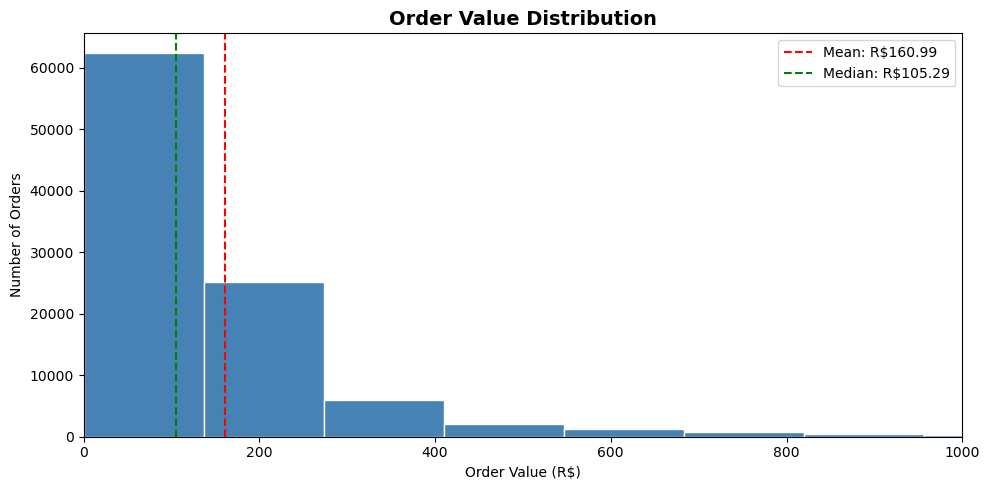

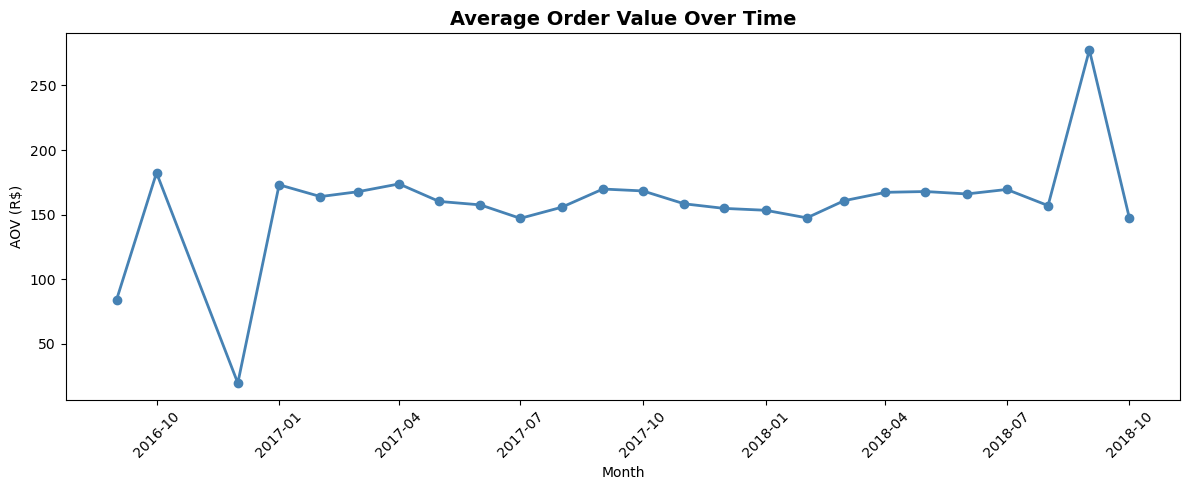

Average Order Value: R$160.99
Median Order Value: R$105.29
Max Order Value: R$13664.08
Min Order Value: R$0.00


In [39]:
# EDA 10: Average Order Value (AOV) Analysis 
# Understand how much customers spend per order

order_aov = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
order_aov.columns = ['order_id', 'order_total']

# Histogram — order value distribution
plt.figure(figsize=(10, 5))
plt.hist(order_aov['order_total'], bins=100, color='steelblue', edgecolor='white')
plt.xlim(0, 1000)  # Focus on main range excluding extreme outliers
plt.axvline(order_aov['order_total'].mean(), color='red', linestyle='--',
            label=f"Mean: R${order_aov['order_total'].mean():.2f}")
plt.axvline(order_aov['order_total'].median(), color='green', linestyle='--',
            label=f"Median: R${order_aov['order_total'].median():.2f}")
plt.title('Order Value Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Order Value (R$)')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

# Line chart — AOV trend over time
order_aov_time = orders[['order_id', 'purchase_yearmonth']].merge(order_aov, on='order_id')
monthly_aov = order_aov_time.groupby('purchase_yearmonth')['order_total'].mean().reset_index()
monthly_aov['purchase_yearmonth'] = monthly_aov['purchase_yearmonth'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly_aov['purchase_yearmonth'], monthly_aov['order_total'],
         marker='o', color='steelblue', linewidth=2)
plt.title('Average Order Value Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('AOV (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Average Order Value: R${order_aov['order_total'].mean():.2f}")
print(f"Median Order Value: R${order_aov['order_total'].median():.2f}")
print(f"Max Order Value: R${order_aov['order_total'].max():.2f}")
print(f"Min Order Value: R${order_aov['order_total'].min():.2f}")

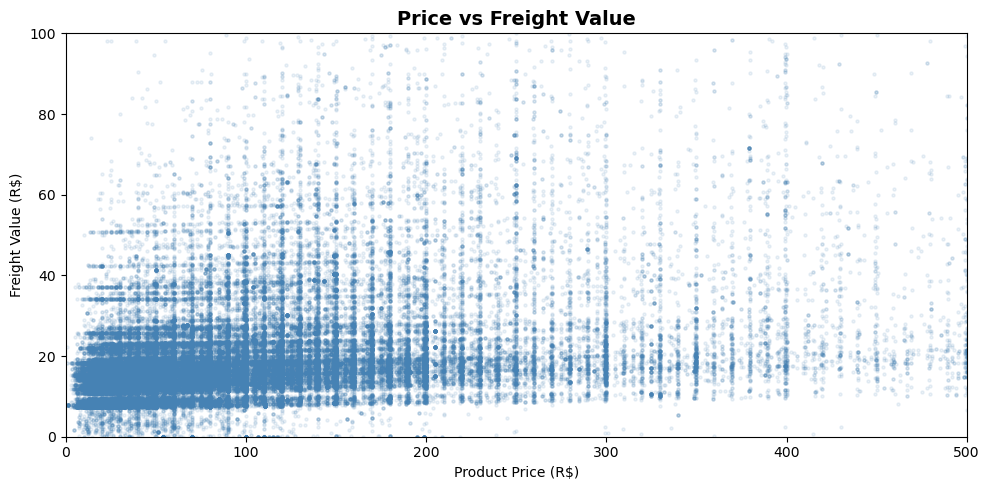

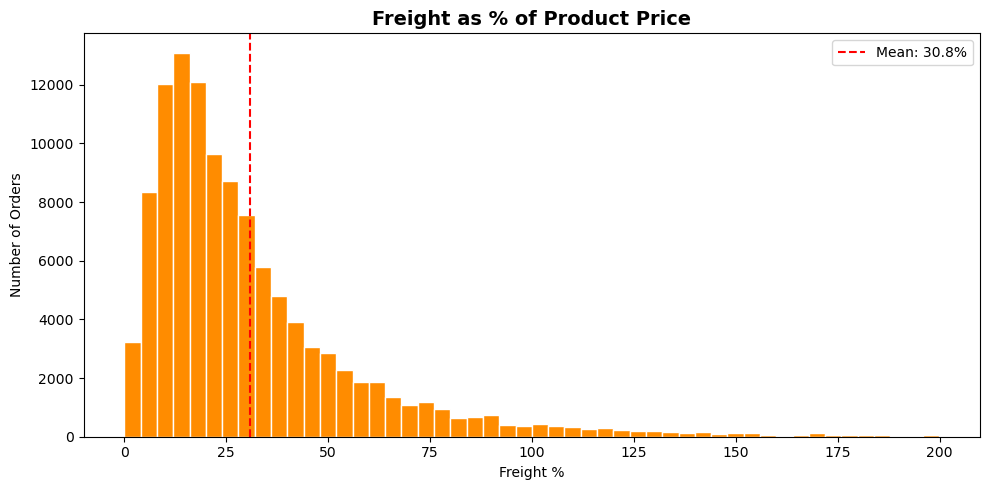

Average freight value: R$19.99
Average freight as % of price: 30.8%
Orders where freight > price: 4,124


In [41]:
# EDA 11: Freight vs Price Analysis 

order_items['freight_percentage'] = (order_items['freight_value'] / order_items['price'] * 100).round(2)
freight_clean = order_items[order_items['freight_percentage'] < 200]

# Plot 1 - Price vs Freight
plt.figure(figsize=(10, 5))
plt.scatter(order_items['price'], order_items['freight_value'], alpha=0.1, color='steelblue', s=5)
plt.xlim(0, 500)
plt.ylim(0, 100)
plt.title('Price vs Freight Value', fontsize=14, fontweight='bold')
plt.xlabel('Product Price (R$)')
plt.ylabel('Freight Value (R$)')
plt.tight_layout()
plt.show()

# Plot 2 - Freight Percentage Distribution
plt.figure(figsize=(10, 5))
plt.hist(freight_clean['freight_percentage'], bins=50, color='darkorange', edgecolor='white')
plt.axvline(freight_clean['freight_percentage'].mean(), color='red', linestyle='--',
            label=f"Mean: {freight_clean['freight_percentage'].mean():.1f}%")
plt.title('Freight as % of Product Price', fontsize=14, fontweight='bold')
plt.xlabel('Freight %')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average freight value: R${order_items['freight_value'].mean():.2f}")
print(f"Average freight as % of price: {freight_clean['freight_percentage'].mean():.1f}%")
print(f"Orders where freight > price: {len(order_items[order_items['freight_value'] > order_items['price']]):,}")

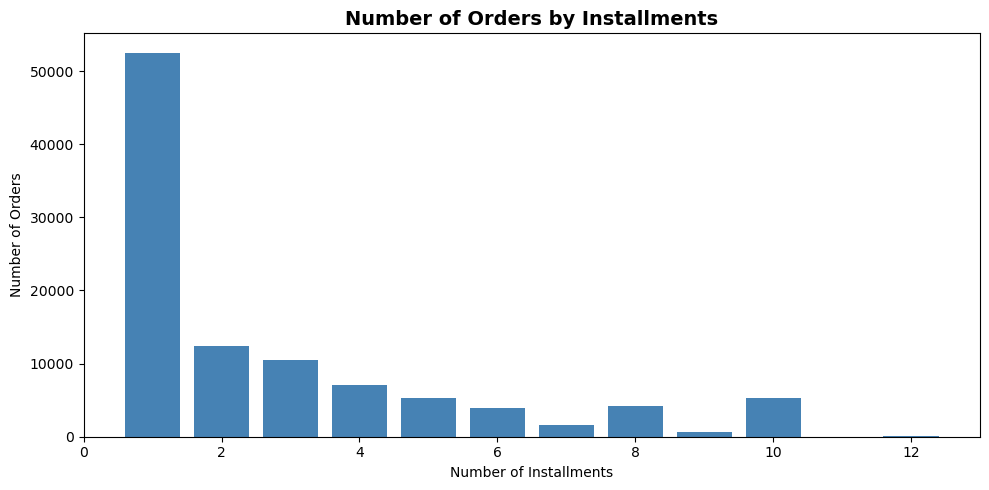

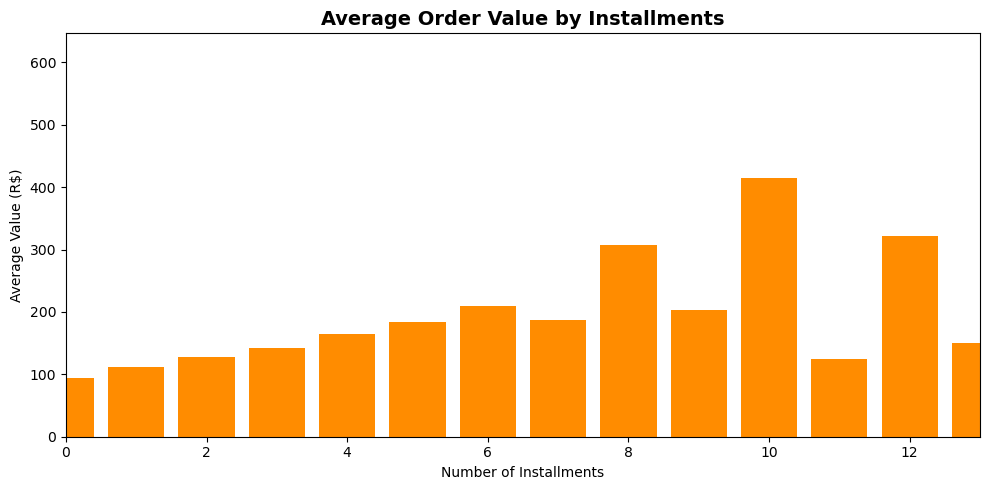

 payment_installments  order_count  avg_value  total_value
                    0            2  94.315000       188.63
                    1        52546 112.420229   5907233.36
                    2        12413 127.228150   1579283.03
                    3        10461 142.539317   1491103.80
                    4         7098 163.976840   1163907.61
                    5         5239 183.465222    961174.30
                    6         3920 209.849952    822611.81
                    7         1626 187.673672    305157.39
                    8         4268 307.737427   1313423.34
                    9          644 203.440870    131015.92
                   10         5328 415.085837   2211577.34
                   11           23 124.932174      2873.44
                   12          133 321.678496     42783.24

Most common installment: 1
Average installments: 2.9


In [42]:
# EDA 12: Installments Analysis 

installments = order_payments.groupby('payment_installments').agg(
    order_count=('order_id', 'count'),
    avg_value=('payment_value', 'mean'),
    total_value=('payment_value', 'sum')
).reset_index()

# Plot 1 - Orders by Installments
plt.figure(figsize=(10, 5))
plt.bar(installments['payment_installments'], installments['order_count'], color='steelblue')
plt.title('Number of Orders by Installments', fontsize=14, fontweight='bold')
plt.xlabel('Number of Installments')
plt.ylabel('Number of Orders')
plt.xlim(0, 13)
plt.tight_layout()
plt.show()

# Plot 2 - Average Order Value by Installments
plt.figure(figsize=(10, 5))
plt.bar(installments['payment_installments'], installments['avg_value'], color='darkorange')
plt.title('Average Order Value by Installments', fontsize=14, fontweight='bold')
plt.xlabel('Number of Installments')
plt.ylabel('Average Value (R$)')
plt.xlim(0, 13)
plt.tight_layout()
plt.show()

print(installments[installments['payment_installments'] <= 12].to_string(index=False))
print(f"\nMost common installment: {order_payments['payment_installments'].mode()[0]}")
print(f"Average installments: {order_payments['payment_installments'].mean():.1f}")

In [44]:
# CONNECT PYTHON TO MYSQL 
from sqlalchemy import create_engine

username = 'root'
password = 'Mysql_08'    
host     = 'localhost'
port     = '3306'
database = 'ecommerce'  # Changed to new database name

engine = create_engine(f'mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}')
print("Connected to MySQL successfully")

Connected to MySQL successfully


In [47]:
# LOAD CLEANED CSVs AND UPLOAD TO MYSQL 
import pandas as pd
from sqlalchemy import create_engine

# Load cleaned CSVs
orders = pd.read_csv('cleaned_orders.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'])

customers = pd.read_csv('cleaned_customers.csv')
order_items = pd.read_csv('cleaned_order_items.csv', parse_dates=['shipping_limit_date'])
order_payments = pd.read_csv('cleaned_order_payments.csv')
order_reviews = pd.read_csv('cleaned_order_reviews.csv', parse_dates=['review_creation_date', 'review_answer_timestamp'])
products = pd.read_csv('cleaned_products.csv')
sellers = pd.read_csv('cleaned_sellers.csv')

print("Cleaned datasets loaded")

# Upload to MySQL
orders.to_sql('orders', engine, if_exists='replace', index=False)
print("orders uploaded")

customers.to_sql('customers', engine, if_exists='replace', index=False)
print("customers uploaded")

order_items.to_sql('order_items', engine, if_exists='replace', index=False)
print("order_items uploaded")

order_payments.to_sql('order_payments', engine, if_exists='replace', index=False)
print("order_payments uploaded")

order_reviews.to_sql('order_reviews', engine, if_exists='replace', index=False)
print("order_reviews uploaded")

products.to_sql('products', engine, if_exists='replace', index=False)
print("products uploaded")

sellers.to_sql('sellers', engine, if_exists='replace', index=False)
print("sellers uploaded")

print("All cleaned tables uploaded to MySQL successfully")

Cleaned datasets loaded
orders uploaded
customers uploaded
order_items uploaded
order_payments uploaded
order_reviews uploaded
products uploaded
sellers uploaded
All cleaned tables uploaded to MySQL successfully


In [48]:
# PULL RFM DATA FROM MYSQL INTO PYTHON 
# Query MySQL to calculate Recency, Frequency and Monetary per customer

rfm_query = """
SELECT 
    c.customer_unique_id                                        AS customer_id,
    DATEDIFF('2018-10-01', MAX(o.order_purchase_timestamp))     AS recency,
    COUNT(DISTINCT o.order_id)                                  AS frequency,
    ROUND(SUM(op.payment_value), 2)                             AS monetary
FROM customers c
JOIN orders o          ON c.customer_id = o.customer_id
JOIN order_payments op ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
ORDER BY monetary DESC;
"""

# Execute query and load into dataframe
rfm_df = pd.read_sql(rfm_query, engine)

print(f"RFM data loaded: {rfm_df.shape[0]} customers")
print(f"\nSample:")
print(rfm_df.head())
print(f"\nStats:")
print(rfm_df.describe())

RFM data loaded: 93357 customers

Sample:
                        customer_id  recency  frequency  monetary
0  0a0a92112bd4c708ca5fde585afaa872      367          1  13664.08
1  da122df9eeddfedc1dc1f5349a1a690c      548          2   7571.63
2  763c8b1c9c68a0229c42c9fc6f662b93       78          1   7274.88
3  dc4802a71eae9be1dd28f5d788ceb526      596          1   6929.31
4  459bef486812aa25204be022145caa62       68          1   6922.21

Stats:
            recency     frequency      monetary
count  93357.000000  93357.000000  93357.000000
mean     270.473783      1.033420    165.198772
std      152.587935      0.209099    226.314579
min       33.000000      1.000000      9.590000
25%      147.000000      1.000000     63.060000
50%      251.000000      1.000000    107.780000
75%      379.000000      1.000000    182.560000
max      728.000000     15.000000  13664.080000


In [49]:
# RFM SCORING 
# Assign scores 1-5 for each R, F, M value
# Recency: lower days = better = higher score
# Frequency: higher orders = better = higher score
# Monetary: higher spend = better = higher score

# Score Recency — lower recency gets higher score
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1])

# Score Frequency — higher frequency gets higher score
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Score Monetary — higher monetary gets higher score
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Convert to integer
rfm_df['r_score'] = rfm_df['r_score'].astype(int)
rfm_df['f_score'] = rfm_df['f_score'].astype(int)
rfm_df['m_score'] = rfm_df['m_score'].astype(int)

# Combined RFM score
rfm_df['rfm_score'] = rfm_df['r_score'].astype(str) + \
                      rfm_df['f_score'].astype(str) + \
                      rfm_df['m_score'].astype(str)

print("RFM Scoring Complete")
print(rfm_df[['customer_id', 'recency', 'frequency', 'monetary', 
              'r_score', 'f_score', 'm_score', 'rfm_score']].head(10))

RFM Scoring Complete
                        customer_id  recency  frequency  monetary  r_score  \
0  0a0a92112bd4c708ca5fde585afaa872      367          1  13664.08        2   
1  da122df9eeddfedc1dc1f5349a1a690c      548          2   7571.63        1   
2  763c8b1c9c68a0229c42c9fc6f662b93       78          1   7274.88        5   
3  dc4802a71eae9be1dd28f5d788ceb526      596          1   6929.31        1   
4  459bef486812aa25204be022145caa62       68          1   6922.21        5   
5  ff4159b92c40ebe40454e3e6a7c35ed6      495          1   6726.66        1   
6  4007669dec559734d6f53e029e360987      311          1   6081.54        2   
7  eebb5dda148d3893cdaf5b5ca3040ccb      531          1   4764.34        1   
8  48e1ac109decbb87765a3eade6854098      101          1   4681.78        5   
9  c8460e4251689ba205045f3ea17884a1       54          4   4655.91        5   

   f_score  m_score rfm_score  
0        1        5       215  
1        5        5       155  
2        1        5     

In [50]:
# RFM SEGMENTATION 
# Assign customer segments based on RFM scores

def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

# Apply segmentation
rfm_df['segment'] = rfm_df.apply(assign_segment, axis=1)

# Segment summary
segment_summary = rfm_df.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(2).reset_index().sort_values('customer_count', ascending=False)

print("RFM Segmentation Complete")
print(f"\nSegment Summary:")
print(segment_summary.to_string(index=False))

RFM Segmentation Complete

Segment Summary:
            segment  customer_count  avg_recency  avg_frequency  avg_monetary
Potential Loyalists           25825       180.08           1.00         69.90
    Needs Attention           18862       396.58           1.00        118.82
      New Customers           15427       124.40           1.00        291.77
   Cannot Lose Them           14585       427.89           1.00        296.88
    Loyal Customers           10506       170.92           1.07        117.21
            At Risk            7157       425.19           1.14        131.90
          Champions             995       121.75           2.18        371.63


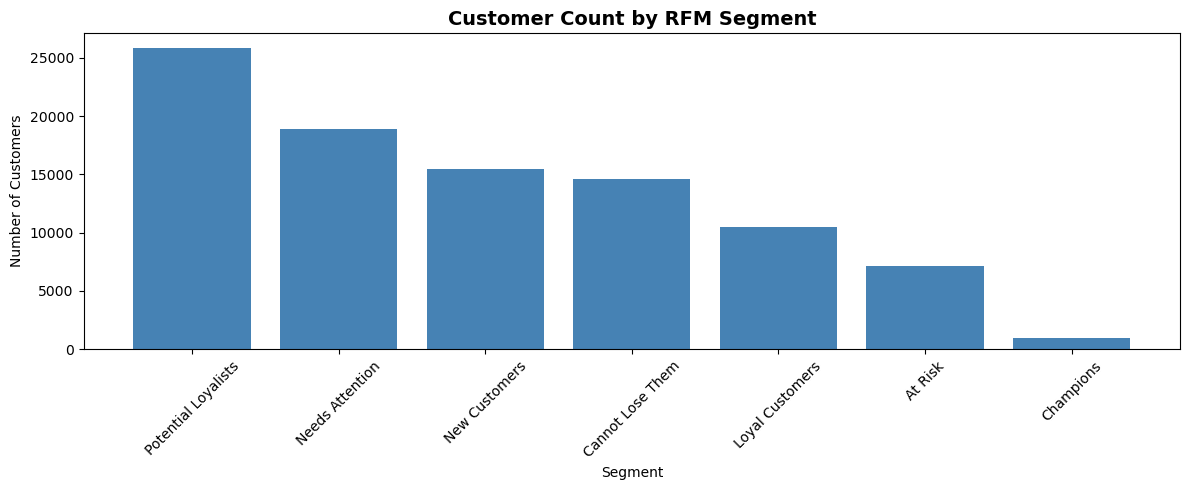

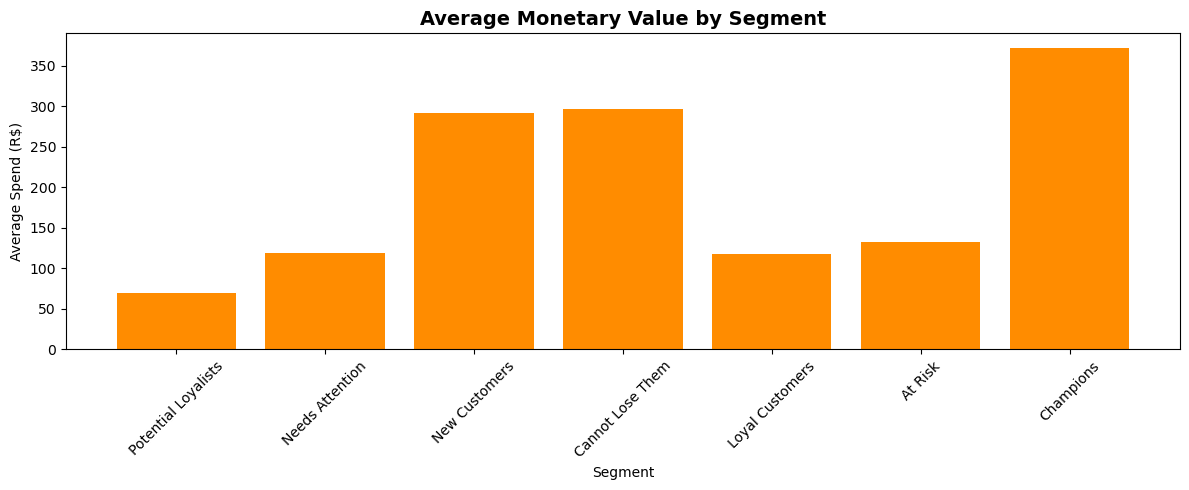

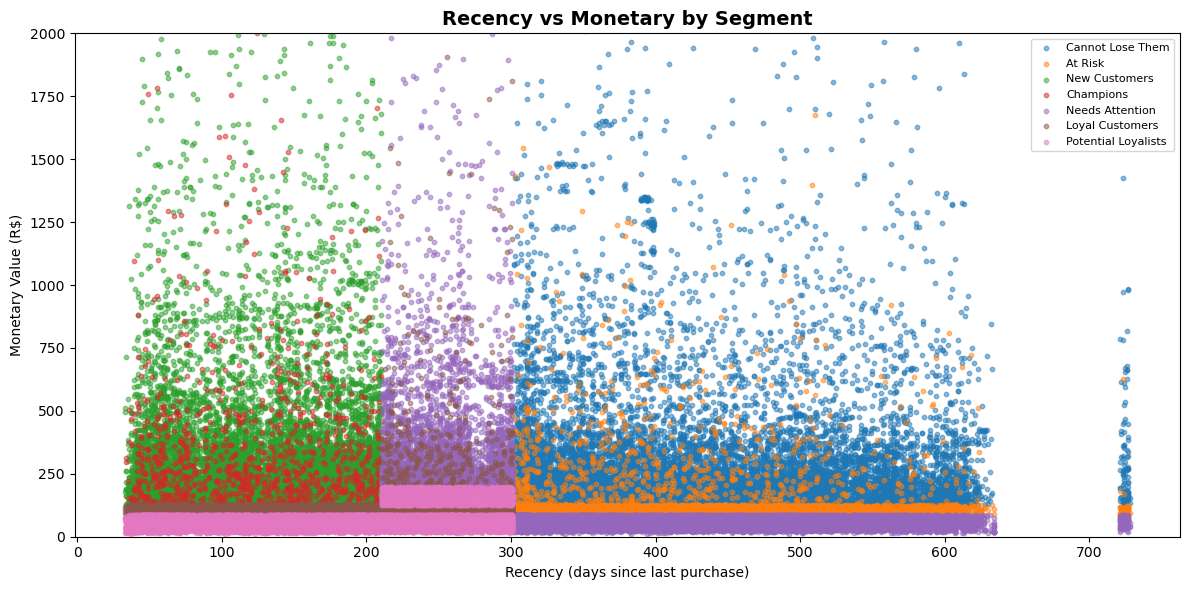

In [55]:
# RFM VISUALISATION

# Plot 1 - Customer count per segment
plt.figure(figsize=(12, 5))
plt.bar(segment_summary['segment'], segment_summary['customer_count'], color='steelblue')
plt.title('Customer Count by RFM Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2 - Average monetary value per segment
plt.figure(figsize=(12, 5))
plt.bar(segment_summary['segment'], segment_summary['avg_monetary'], color='darkorange')
plt.title('Average Monetary Value by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Average Spend (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3 - RFM Scatter plot — Recency vs Monetary coloured by segment
plt.figure(figsize=(12, 6))
segments = rfm_df['segment'].unique()
colors = sns.color_palette('tab10', len(segments))

for seg, color in zip(segments, colors):
    subset = rfm_df[rfm_df['segment'] == seg]
    plt.scatter(subset['recency'], subset['monetary'],
                label=seg, alpha=0.5, s=10, color=color)

plt.title('Recency vs Monetary by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value (R$)')
plt.legend(loc='upper right', fontsize=8)
plt.ylim(0, 2000)
plt.tight_layout()
plt.show()

In [57]:
# Export RFM results to MySQL
rfm_df.to_sql('rfm_segments', engine, if_exists='replace', index=False)
print("RFM data uploaded to MySQL")

RFM data uploaded to MySQL


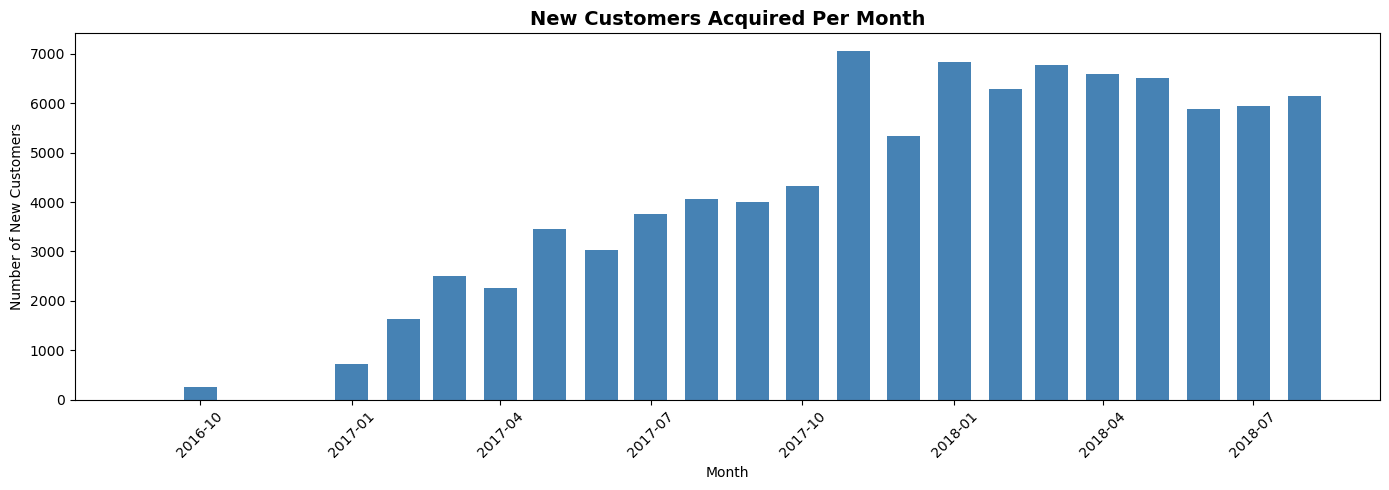

Total new customers: 93,358
Peak acquisition month: November 2017
Peak new customers: 7,060


In [59]:
#  SECTION 4 — COHORT ANALYSIS
#  (Order-based cohort — monthly order trends)

# MONTHLY ORDER COHORT 
# Since most customers buy once, we analyse order cohorts
# by month — how many new customers joined each month

new_customers_query = """
SELECT 
    DATE_FORMAT(MIN(o.order_purchase_timestamp), '%Y-%m') AS cohort_month,
    COUNT(DISTINCT c.customer_unique_id)                   AS new_customers
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
"""

new_customers_df = pd.read_sql(new_customers_query, engine)

# Group by cohort month
monthly_new = new_customers_df.groupby('cohort_month')['new_customers'].sum().reset_index()
monthly_new['cohort_month'] = pd.to_datetime(monthly_new['cohort_month'])
monthly_new = monthly_new.sort_values('cohort_month')

# Plot — new customers acquired per month
plt.figure(figsize=(14, 5))
plt.bar(monthly_new['cohort_month'], monthly_new['new_customers'],
        color='steelblue', width=20)
plt.title('New Customers Acquired Per Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of New Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total new customers: {monthly_new['new_customers'].sum():,}")
print(f"Peak acquisition month: {monthly_new.loc[monthly_new['new_customers'].idxmax(), 'cohort_month'].strftime('%B %Y')}")
print(f"Peak new customers: {monthly_new['new_customers'].max():,}")

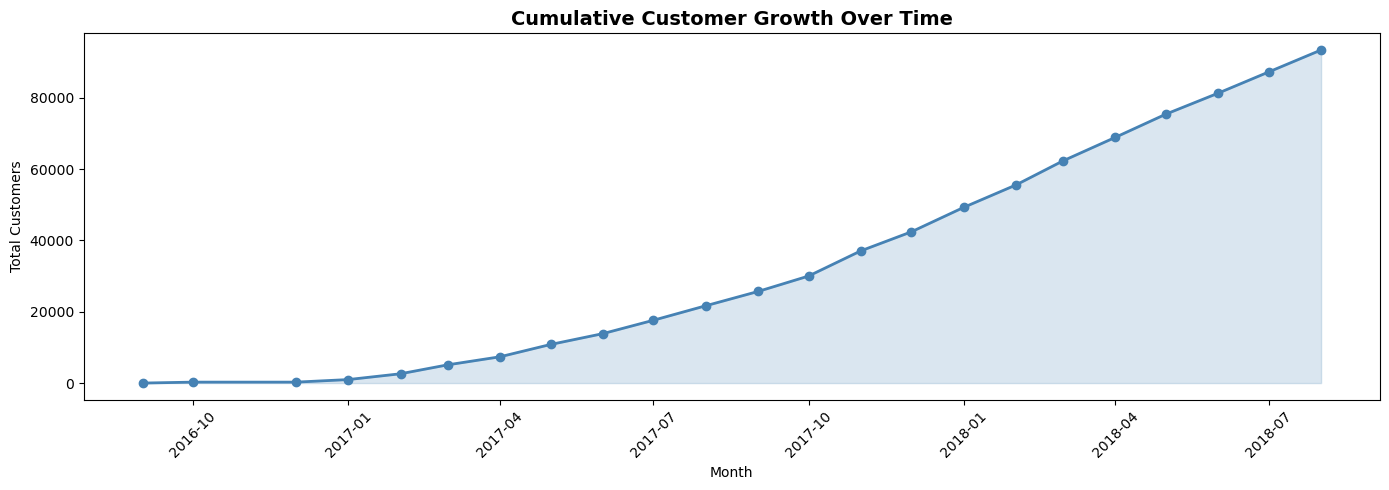

cohort_month  new_customers  cumulative_customers
  2016-09-01              1                     1
  2016-10-01            262                   263
  2016-12-01              1                   264
  2017-01-01            717                   981
  2017-02-01           1628                  2609
  2017-03-01           2503                  5112
  2017-04-01           2256                  7368
  2017-05-01           3451                 10819
  2017-06-01           3037                 13856
  2017-07-01           3752                 17608
  2017-08-01           4057                 21665
  2017-09-01           4004                 25669
  2017-10-01           4328                 29997
  2017-11-01           7060                 37057
  2017-12-01           5338                 42395
  2018-01-01           6842                 49237
  2018-02-01           6288                 55525
  2018-03-01           6774                 62299
  2018-04-01           6582                 68881


In [61]:
# CUMULATIVE CUSTOMER GROWTH 
# Show how total customer base grew over time

monthly_new['cumulative_customers'] = monthly_new['new_customers'].cumsum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_new['cohort_month'], monthly_new['cumulative_customers'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly_new['cohort_month'],
                 monthly_new['cumulative_customers'],
                 alpha=0.2, color='steelblue')
plt.title('Cumulative Customer Growth Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly_new.to_string(index=False))

In [63]:
#  SECTION 5 — CUSTOMER LIFETIME VALUE (CLV) ANALYSIS

# PULL CLV DATA FROM MYSQL 
# Calculate CLV per customer — total spend, orders, avg order value

clv_query = """
SELECT 
    c.customer_unique_id                        AS customer_id,
    COUNT(DISTINCT o.order_id)                  AS total_orders,
    ROUND(SUM(op.payment_value), 2)             AS total_spend,
    ROUND(AVG(op.payment_value), 2)             AS avg_order_value,
    DATEDIFF(MAX(o.order_purchase_timestamp),
             MIN(o.order_purchase_timestamp))   AS customer_lifespan_days,
    DATE_FORMAT(MIN(o.order_purchase_timestamp), '%Y-%m') AS first_purchase,
    DATE_FORMAT(MAX(o.order_purchase_timestamp), '%Y-%m') AS last_purchase
FROM customers c
JOIN orders o          ON c.customer_id = o.customer_id
JOIN order_payments op ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
ORDER BY total_spend DESC;
"""

clv_df = pd.read_sql(clv_query, engine)

print(f"CLV data loaded: {clv_df.shape[0]} customers")
print(f"\nSample:")
print(clv_df.head())
print(f"\nStats:")
print(clv_df.describe())

CLV data loaded: 93357 customers

Sample:
                        customer_id  total_orders  total_spend  \
0  0a0a92112bd4c708ca5fde585afaa872             1     13664.08   
1  da122df9eeddfedc1dc1f5349a1a690c             2      7571.63   
2  763c8b1c9c68a0229c42c9fc6f662b93             1      7274.88   
3  dc4802a71eae9be1dd28f5d788ceb526             1      6929.31   
4  459bef486812aa25204be022145caa62             1      6922.21   

   avg_order_value  customer_lifespan_days first_purchase last_purchase  
0         13664.08                       0        2017-09       2017-09  
1          3785.82                       0        2017-04       2017-04  
2          7274.88                       0        2018-07       2018-07  
3          6929.31                       0        2017-02       2017-02  
4          6922.21                       0        2018-07       2018-07  

Stats:
       total_orders   total_spend  avg_order_value  customer_lifespan_days
count  93357.000000  93357.000000 

In [65]:
# CLV CALCULATION 
# Calculate CLV segments based on total spend

# CLV Segmentation based on total spend
clv_df['clv_segment'] = pd.cut(
    clv_df['total_spend'],
    bins=[0, 100, 300, 600, 1000, float('inf')],
    labels=['Low (0-100)', 'Medium (100-300)', 'High (300-600)', 
            'Very High (600-1000)', 'Premium (1000+)']
)

# Summary by CLV segment
clv_summary = clv_df.groupby('clv_segment').agg(
    customer_count=('customer_id', 'count'),
    avg_spend=('total_spend', 'mean'),
    total_revenue=('total_spend', 'sum'),
    avg_orders=('total_orders', 'mean')
).round(2).reset_index()

clv_summary['revenue_percentage'] = (
    clv_summary['total_revenue'] / 
    clv_summary['total_revenue'].sum() * 100
).round(2)

print("CLV Segmentation Complete")
print(clv_summary.to_string(index=False))

CLV Segmentation Complete
         clv_segment  customer_count  avg_spend  total_revenue  avg_orders  revenue_percentage
         Low (0-100)           43249      60.36     2610659.26        1.01               16.93
    Medium (100-300)           39771     166.01     6602390.34        1.04               42.81
      High (300-600)            7125     399.48     2846263.27        1.11               18.46
Very High (600-1000)            2063     747.84     1542786.87        1.13               10.00
     Premium (1000+)            1149    1584.30     1820362.03        1.11               11.80


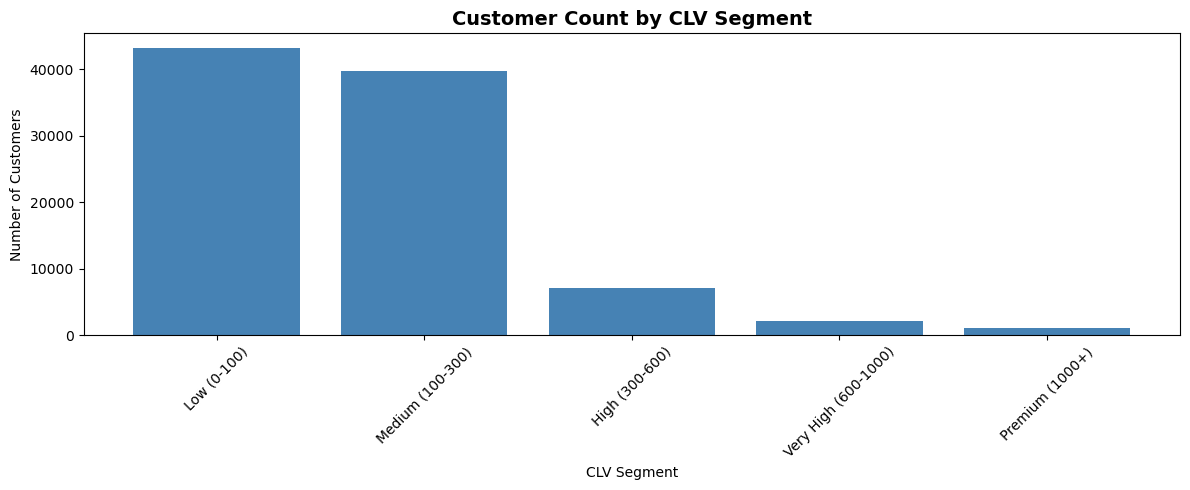

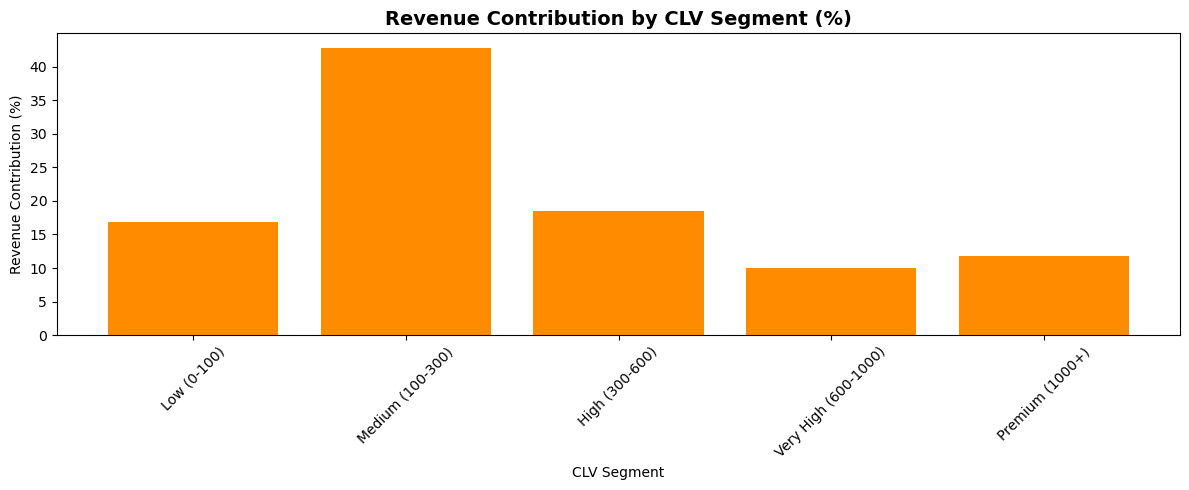

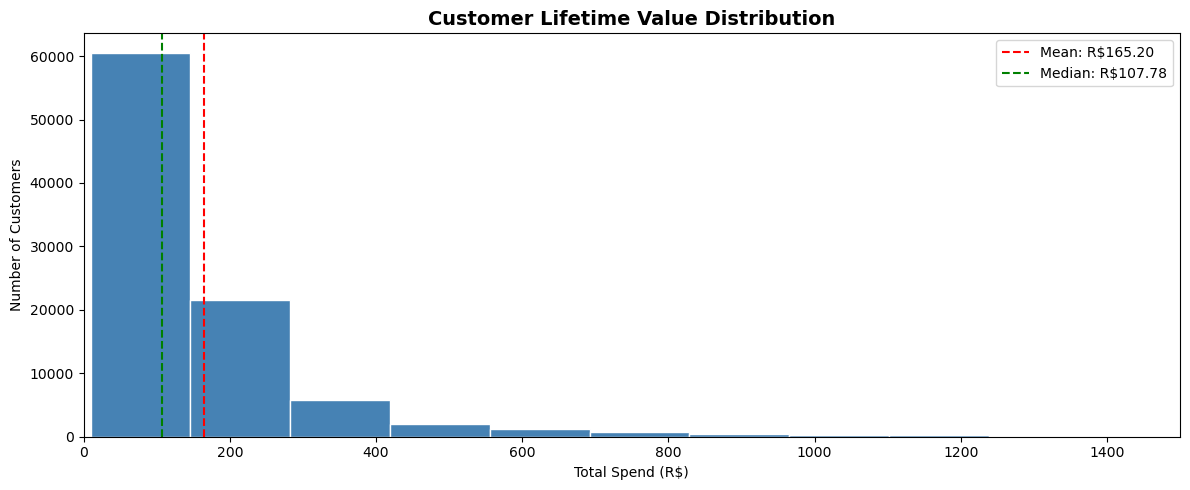

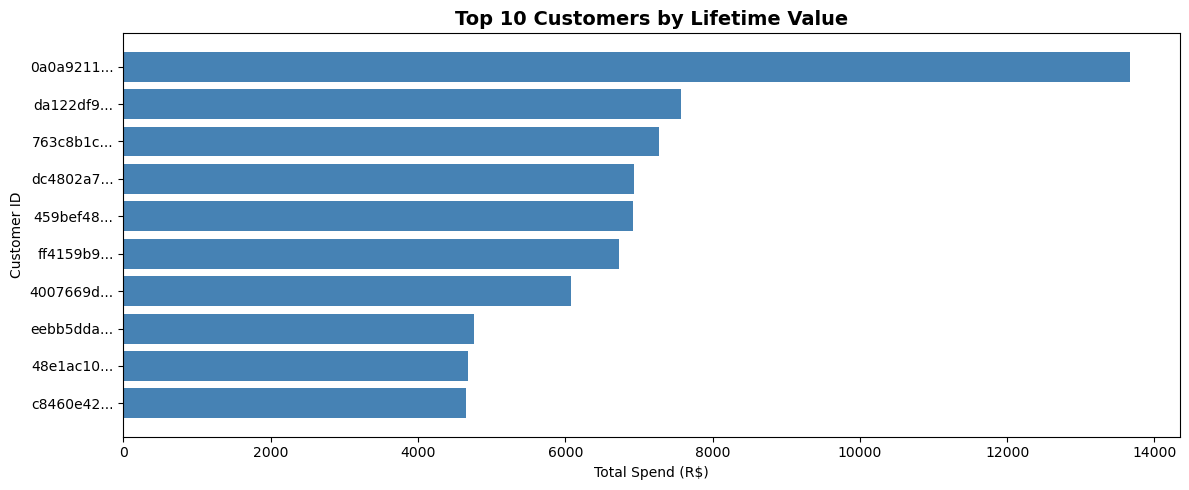


Total Revenue: R$15,422,461.77
Average CLV: R$165.20
Median CLV: R$107.78
Top 10% CLV threshold: R$318.08


In [67]:
# CLV VISUALISATIONS 
# Plot 1 — Customer count by CLV segment
plt.figure(figsize=(12, 5))
plt.bar(clv_summary['clv_segment'], clv_summary['customer_count'], color='steelblue')
plt.title('Customer Count by CLV Segment', fontsize=14, fontweight='bold')
plt.xlabel('CLV Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2 — Revenue contribution by CLV segment
plt.figure(figsize=(12, 5))
plt.bar(clv_summary['clv_segment'], clv_summary['revenue_percentage'], color='darkorange')
plt.title('Revenue Contribution by CLV Segment (%)', fontsize=14, fontweight='bold')
plt.xlabel('CLV Segment')
plt.ylabel('Revenue Contribution (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3 — CLV distribution histogram
plt.figure(figsize=(12, 5))
plt.hist(clv_df['total_spend'], bins=100, color='steelblue', edgecolor='white')
plt.xlim(0, 1500)
plt.axvline(clv_df['total_spend'].mean(), color='red', linestyle='--',
            label=f"Mean: R${clv_df['total_spend'].mean():.2f}")
plt.axvline(clv_df['total_spend'].median(), color='green', linestyle='--',
            label=f"Median: R${clv_df['total_spend'].median():.2f}")
plt.title('Customer Lifetime Value Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend (R$)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 4 — Top 10 highest value customers
top_customers = clv_df.nlargest(10, 'total_spend')[['customer_id', 'total_spend', 'total_orders']]
top_customers['customer_short'] = top_customers['customer_id'].str[:8] + '...'

plt.figure(figsize=(12, 5))
plt.barh(top_customers['customer_short'], top_customers['total_spend'], color='steelblue')
plt.title('Top 10 Customers by Lifetime Value', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend (R$)')
plt.ylabel('Customer ID')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal Revenue: R${clv_df['total_spend'].sum():,.2f}")
print(f"Average CLV: R${clv_df['total_spend'].mean():.2f}")
print(f"Median CLV: R${clv_df['total_spend'].median():.2f}")
print(f"Top 10% CLV threshold: R${clv_df['total_spend'].quantile(0.90):.2f}")

In [71]:
# Export CLV results to MySQL
clv_df.to_sql('clv_segments', engine, if_exists='replace', index=False)
print("CLV data uploaded to MySQL")

CLV data uploaded to MySQL


In [69]:
#  SECTION 6 — SELLER PERFORMANCE ANALYSIS

# PULL SELLER DATA FROM MYSQL 
# Get seller revenue, orders, and average rating

seller_query = """
SELECT 
    oi.seller_id,
    s.seller_city,
    s.seller_state,
    COUNT(DISTINCT oi.order_id)         AS total_orders,
    ROUND(SUM(oi.price), 2)             AS total_revenue,
    ROUND(AVG(oi.price), 2)             AS avg_price,
    ROUND(AVG(r.review_score), 2)       AS avg_review_score,
    ROUND(AVG(DATEDIFF(
        o.order_delivered_customer_date,
        o.order_purchase_timestamp)), 1) AS avg_delivery_days
FROM order_items oi
JOIN sellers s      ON oi.seller_id = s.seller_id
JOIN orders o       ON oi.order_id = o.order_id
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY oi.seller_id, s.seller_city, s.seller_state
ORDER BY total_revenue DESC;
"""

seller_df = pd.read_sql(seller_query, engine)

print(f"Seller data loaded: {seller_df.shape[0]} sellers")
print(f"\nSample:")
print(seller_df.head())
print(f"\nStats:")
print(seller_df.describe())

Seller data loaded: 2965 sellers

Sample:
                          seller_id       seller_city seller_state  \
0  4869f7a5dfa277a7dca6462dcf3b52b2           guariba           SP   
1  53243585a1d6dc2643021fd1853d8905  lauro de freitas           BA   
2  4a3ca9315b744ce9f8e9374361493884          ibitinga           SP   
3  fa1c13f2614d7b5c4749cbc52fecda94            sumare           SP   
4  7c67e1448b00f6e969d365cea6b010ab   itaquaquecetuba           SP   

   total_orders  total_revenue  avg_price  avg_review_score  avg_delivery_days  
0          1116      225586.34     197.88              4.14               14.9  
1           346      215904.44     542.47              4.13               13.2  
2          1753      197225.32     101.19              3.83               14.4  
3           574      189649.54     329.83              4.37               13.2  
4           967      186664.01     137.46              3.35               22.3  

Stats:
       total_orders  total_revenue    avg_p

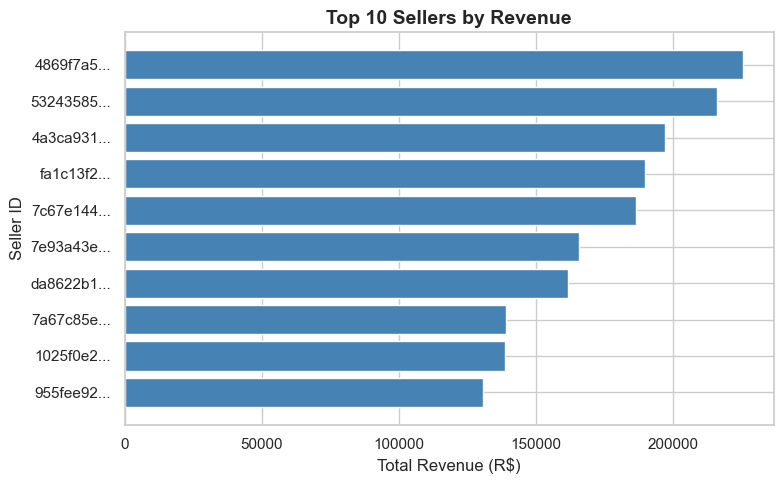

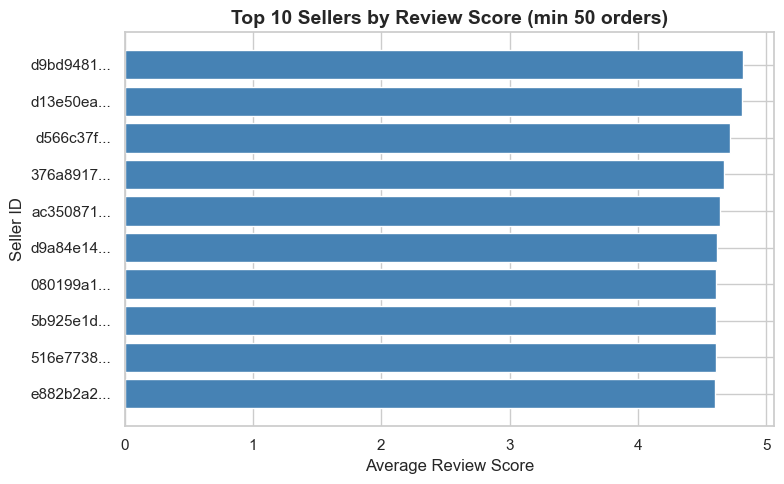

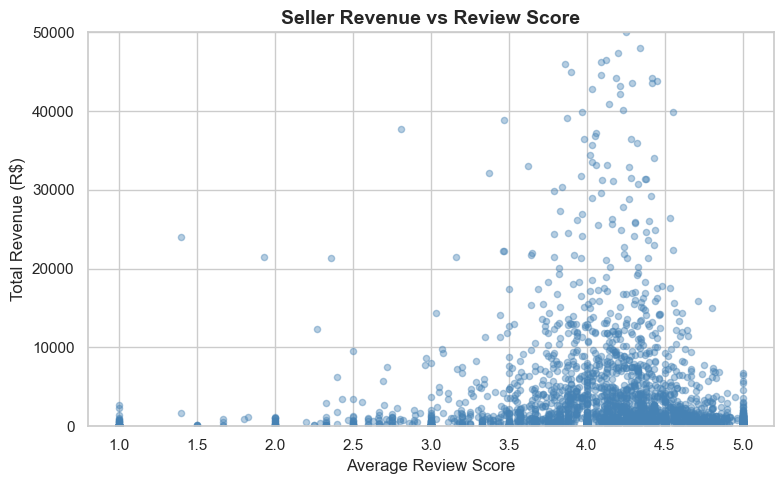

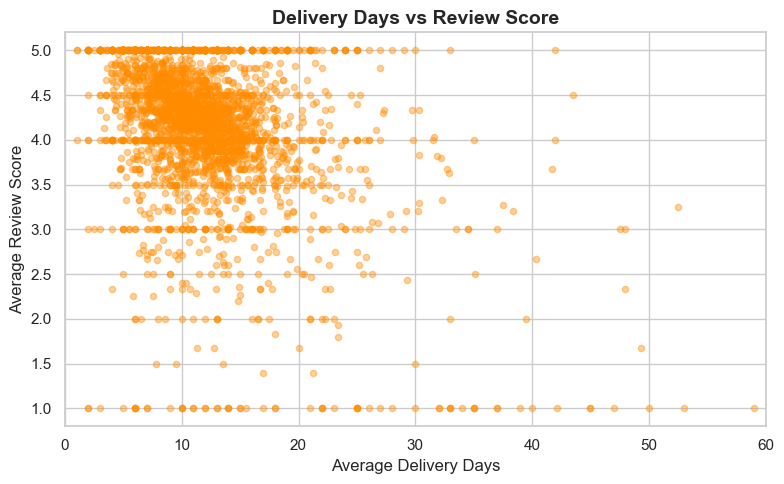

Total sellers: 2,965
Average review score: 4.15
Average delivery days: 12.0
Sellers with review score above 4.5: 1,077
Sellers with delivery > 30 days: 56


In [75]:
# SELLER PERFORMANCE VISUALISATIONS 

# Top 10 sellers by revenue
top_sellers = seller_df.nlargest(10, 'total_revenue').copy()
top_sellers['seller_short'] = top_sellers['seller_id'].str[:8] + '...'

# Plot 1 — Top 10 sellers by revenue
plt.figure(figsize=(8, 5))
plt.barh(top_sellers['seller_short'], top_sellers['total_revenue'], color='steelblue')
plt.title('Top 10 Sellers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Seller ID')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot 2 — Top 10 sellers by review score (min 50 orders)
top_rated = seller_df[seller_df['total_orders'] >= 50]\
    .nlargest(10, 'avg_review_score').copy()
top_rated['seller_short'] = top_rated['seller_id'].str[:8] + '...'

plt.figure(figsize=(8, 5))
plt.barh(top_rated['seller_short'], top_rated['avg_review_score'], color='steelblue')
plt.title('Top 10 Sellers by Review Score (min 50 orders)', fontsize=14, fontweight='bold')
plt.xlabel('Average Review Score')
plt.ylabel('Seller ID')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot 3 — Revenue vs Review Score scatter
plt.figure(figsize=(8, 5))
plt.scatter(seller_df['avg_review_score'], seller_df['total_revenue'],
            alpha=0.4, color='steelblue', s=20)
plt.ylim(0, 50000)
plt.title('Seller Revenue vs Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Average Review Score')
plt.ylabel('Total Revenue (R$)')
plt.tight_layout()
plt.show()

# Plot 4 — Delivery days vs Review Score
plt.figure(figsize=(8, 5))
plt.scatter(seller_df['avg_delivery_days'], seller_df['avg_review_score'],
            alpha=0.4, color='darkorange', s=20)
plt.xlim(0, 60)
plt.title('Delivery Days vs Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Average Delivery Days')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()

# Summary stats
print(f"Total sellers: {len(seller_df):,}")
print(f"Average review score: {seller_df['avg_review_score'].mean():.2f}")
print(f"Average delivery days: {seller_df['avg_delivery_days'].mean():.1f}")
print(f"Sellers with review score above 4.5: {len(seller_df[seller_df['avg_review_score'] >= 4.5]):,}")
print(f"Sellers with delivery > 30 days: {len(seller_df[seller_df['avg_delivery_days'] > 30]):,}")

In [77]:
#  SECTION 7 — GEOLOCATION ANALYSIS

# PULL GEOLOCATION DATA FROM MYSQL 
# Get orders with customer location and revenue by state

geo_query = """
SELECT 
    c.customer_state                            AS state,
    COUNT(DISTINCT o.order_id)                  AS total_orders,
    COUNT(DISTINCT c.customer_unique_id)        AS total_customers,
    ROUND(SUM(op.payment_value), 2)             AS total_revenue,
    ROUND(AVG(op.payment_value), 2)             AS avg_order_value,
    ROUND(AVG(DATEDIFF(
        o.order_delivered_customer_date,
        o.order_purchase_timestamp)), 1)         AS avg_delivery_days,
    ROUND(AVG(oi.freight_value), 2)             AS avg_freight
FROM customers c
JOIN orders o          ON c.customer_id = o.customer_id
JOIN order_payments op ON o.order_id = op.order_id
JOIN order_items oi    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_revenue DESC;
"""

geo_df = pd.read_sql(geo_query, engine)

print(f"Geolocation data loaded: {geo_df.shape[0]} states")
print(f"\nSample:")
print(geo_df.head(10))

Geolocation data loaded: 27 states

Sample:
  state  total_orders  total_customers  total_revenue  avg_order_value  \
0    SP         40500            39155     7403993.29           152.59   
1    RJ         12350            11917     2688933.90           180.79   
2    MG         11354            11001     2281229.16           170.03   
3    RS          5345             5168     1110976.47           174.05   
4    PR          4923             4769     1030822.39           175.67   
5    BA          3256             3158      773182.02           196.74   
6    SC          3546             3449      767093.97           181.69   
7    GO          1957             1895      493068.70           207.87   
8    DF          2080             2019      421374.86           174.05   
9    ES          1995             1928      398321.90           172.66   

   avg_delivery_days  avg_freight  
0                8.7        15.17  
1               15.2        21.06  
2               11.9        20.62

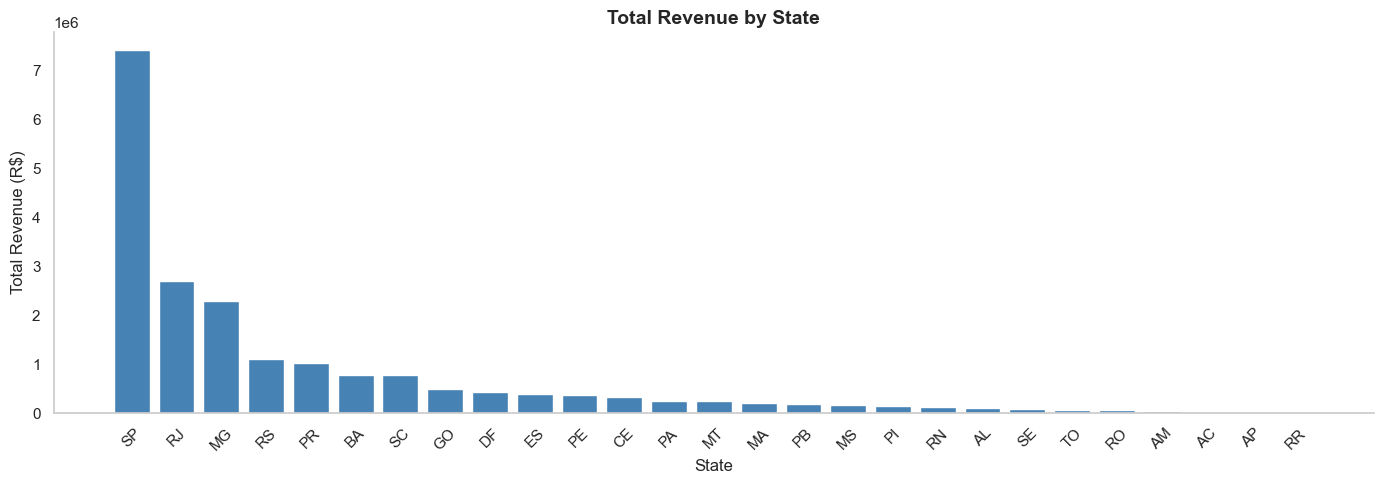

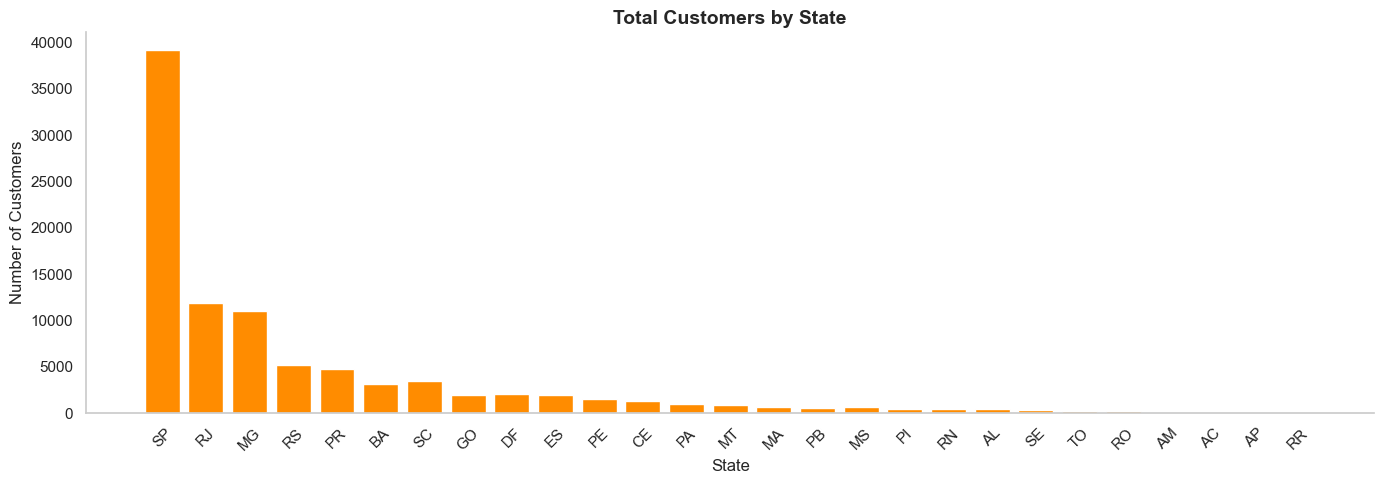

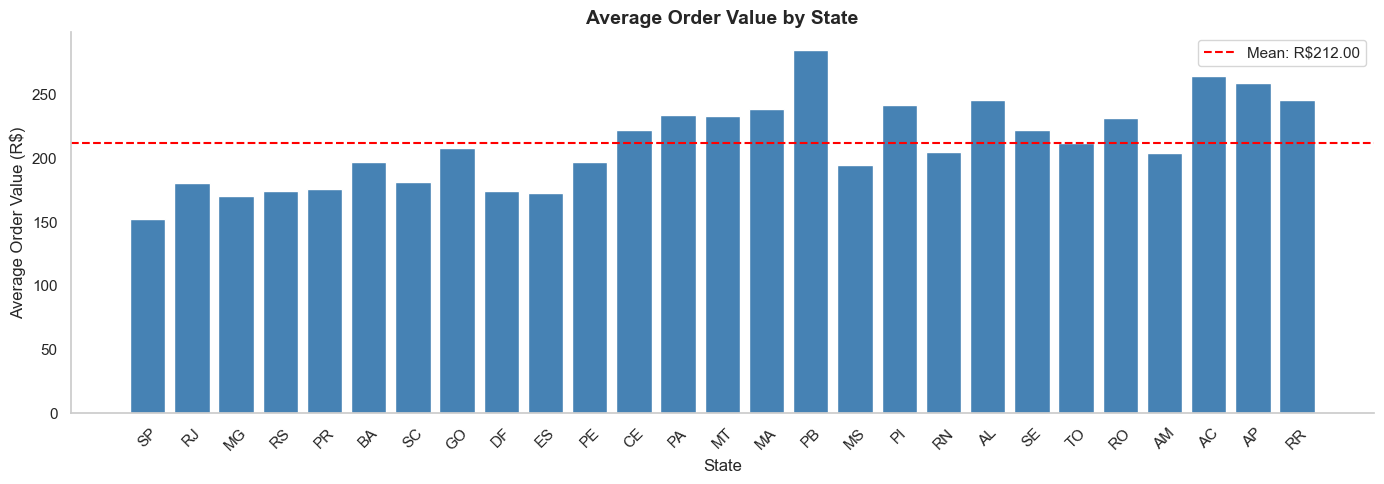

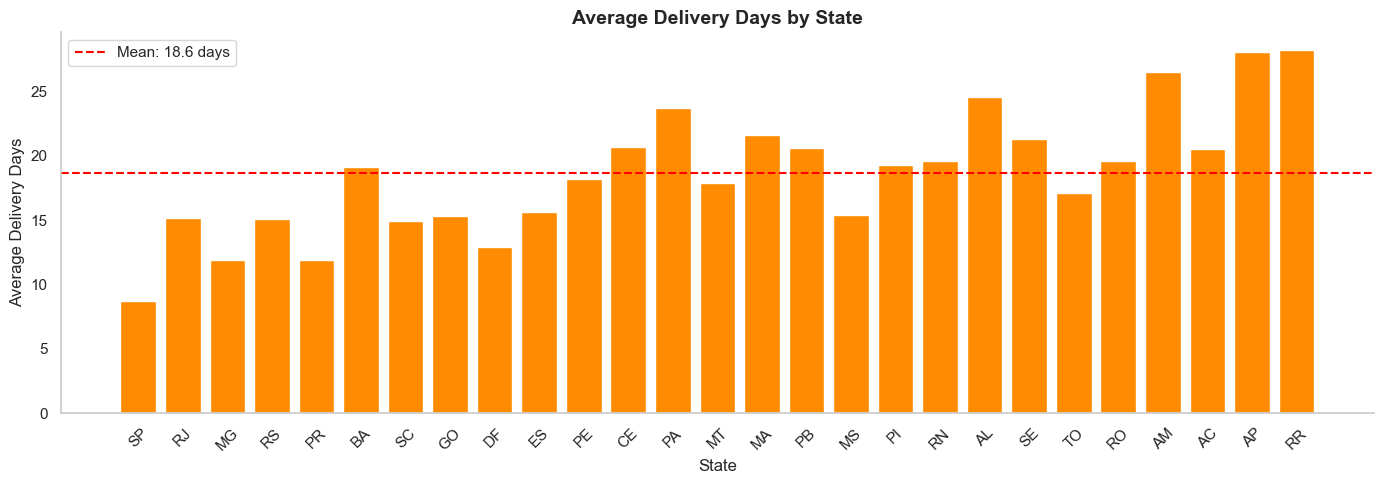

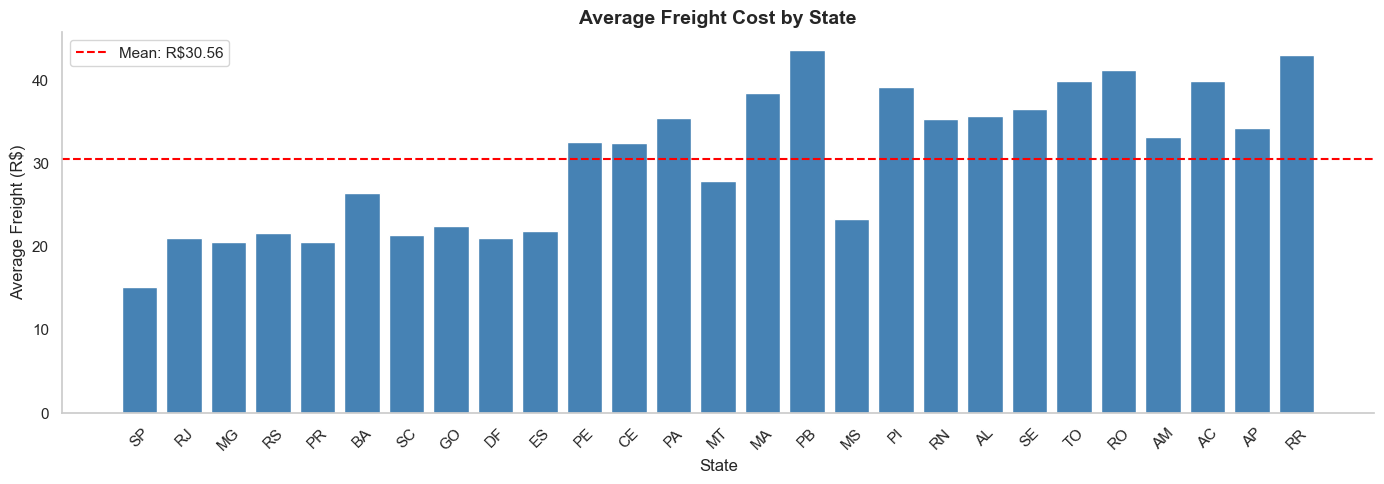

State with highest revenue: SP — R$7,403,993.29
State with highest AOV: PB — R$284.70
State with fastest delivery: SP — 8.7 days
State with slowest delivery: RR — 28.2 days
State with highest freight: PB — R$43.62


In [85]:
# GEOLOCATION VISUALISATIONS

# Plot 1 — Total Revenue by State
plt.figure(figsize=(14, 5))
plt.bar(geo_df['state'], geo_df['total_revenue'], color='steelblue')
plt.title('Total Revenue by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Revenue (R$)')
plt.xticks(rotation=45)
plt.gca().grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Plot 2 — Total Customers by State
plt.figure(figsize=(14, 5))
plt.bar(geo_df['state'], geo_df['total_customers'], color='darkorange')
plt.title('Total Customers by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.gca().grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Plot 3 — Average Order Value by State
plt.figure(figsize=(14, 5))
plt.bar(geo_df['state'], geo_df['avg_order_value'], color='steelblue')
plt.axhline(geo_df['avg_order_value'].mean(), color='red', linestyle='--',
            label=f"Mean: R${geo_df['avg_order_value'].mean():.2f}")
plt.title('Average Order Value by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Average Order Value (R$)')
plt.xticks(rotation=45)
plt.legend()
plt.gca().grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Plot 4 — Average Delivery Days by State
plt.figure(figsize=(14, 5))
plt.bar(geo_df['state'], geo_df['avg_delivery_days'], color='darkorange')
plt.axhline(geo_df['avg_delivery_days'].mean(), color='red', linestyle='--',
            label=f"Mean: {geo_df['avg_delivery_days'].mean():.1f} days")
plt.title('Average Delivery Days by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=45)
plt.legend()
plt.gca().grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Plot 5 — Average Freight by State
plt.figure(figsize=(14, 5))
plt.bar(geo_df['state'], geo_df['avg_freight'], color='steelblue')
plt.axhline(geo_df['avg_freight'].mean(), color='red', linestyle='--',
            label=f"Mean: R${geo_df['avg_freight'].mean():.2f}")
plt.title('Average Freight Cost by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Average Freight (R$)')
plt.xticks(rotation=45)
plt.legend()
plt.gca().grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Summary
print(f"State with highest revenue: {geo_df.loc[geo_df['total_revenue'].idxmax(), 'state']} — R${geo_df['total_revenue'].max():,.2f}")
print(f"State with highest AOV: {geo_df.loc[geo_df['avg_order_value'].idxmax(), 'state']} — R${geo_df['avg_order_value'].max():.2f}")
print(f"State with fastest delivery: {geo_df.loc[geo_df['avg_delivery_days'].idxmin(), 'state']} — {geo_df['avg_delivery_days'].min():.1f} days")
print(f"State with slowest delivery: {geo_df.loc[geo_df['avg_delivery_days'].idxmax(), 'state']} — {geo_df['avg_delivery_days'].max():.1f} days")
print(f"State with highest freight: {geo_df.loc[geo_df['avg_freight'].idxmax(), 'state']} — R${geo_df['avg_freight'].max():.2f}")

In [91]:
# ══════════════════════════════════════════════════════
#  SECTION 8 — INSIGHTS & RECOMMENDATIONS
# ══════════════════════════════════════════════════════

print("""
        KEY INSIGHTS & BUSINESS RECOMMENDATIONS              

── INSIGHT 1: STRONG BUSINESS GROWTH ─────────────────────────
- Orders grew consistently from 2016 to peak in Nov 2017
- 93,358 unique customers acquired over 2 years
- Peak acquisition month was November 2017 (Black Friday effect)
- RECOMMENDATION: Invest heavily in Black Friday campaigns
  as this is clearly the strongest acquisition period

── INSIGHT 2: RETENTION IS THE BIGGEST CHALLENGE ─────────────
- 97% of customers only purchased once
- Average customer lifespan is near 0 days
- Only 995 Champions out of 93,357 customers (1%)
- RECOMMENDATION: Introduce loyalty programme, email
  re-engagement campaigns and personalised offers to
  convert one-time buyers into repeat customers

── INSIGHT 3: HIGH VALUE CUSTOMERS NEED PROTECTING ───────────
- 14,585 customers in "Cannot Lose Them" segment
- They have high spend but have gone cold
- Premium customers (1,149) contribute 11.8% of revenue
- RECOMMENDATION: Create VIP programme for premium customers
  and targeted win-back campaigns for Cannot Lose Them segment

── INSIGHT 4: PAYMENT BEHAVIOUR ──────────────────────────────
- Credit card is dominant payment method
- Customers paying in more installments spend more
- Average installments is 2.9
- RECOMMENDATION: Promote higher installment options to
  increase average order value

── INSIGHT 5: DELIVERY PERFORMANCE IS STRONG ─────────────────
- Average actual delivery is 12 days vs 23 days estimated
- Most orders arrive early — positive customer experience
- RECOMMENDATION: Use early delivery as a marketing message
  to build trust and differentiate from competitors

── INSIGHT 6: CATEGORY OPPORTUNITIES ─────────────────────────
- Top categories dominate revenue heavily
- Long tail of low performing categories
- RECOMMENDATION: Focus marketing spend on top categories
  while reviewing viability of bottom performers

── INSIGHT 7: SELLER PERFORMANCE ─────────────────────────────
- Top seller generated R$225,586 in revenue
- Average seller review score is 4.15 out of 5
- Some sellers have average delivery of 190 days — major outlier
- RECOMMENDATION: Introduce seller performance standards
  with minimum review score and maximum delivery time thresholds
  to protect customer experience

── INSIGHT 8: GEOGRAPHIC CONCENTRATION ───────────────────────
- São Paulo alone accounts for majority of orders and revenue
- Remote states have significantly higher freight costs
- States further from SP have longer delivery times
- RECOMMENDATION: Expand seller network in underserved states
  to reduce freight costs and delivery times
  unlocking growth in untapped regions

── INSIGHT 9: FREIGHT IMPACT ─────────────────────────────────
- Average freight is R$20 — roughly 15% of order value
- Some states pay disproportionately high freight
- High freight likely discourages purchases in remote regions
- RECOMMENDATION: Introduce free freight thresholds or
  subsidised shipping for high freight states to
  drive order volume in those regions
""")


        KEY INSIGHTS & BUSINESS RECOMMENDATIONS              

── INSIGHT 1: STRONG BUSINESS GROWTH ─────────────────────────
- Orders grew consistently from 2016 to peak in Nov 2017
- 93,358 unique customers acquired over 2 years
- Peak acquisition month was November 2017 (Black Friday effect)
- RECOMMENDATION: Invest heavily in Black Friday campaigns
  as this is clearly the strongest acquisition period

── INSIGHT 2: RETENTION IS THE BIGGEST CHALLENGE ─────────────
- 97% of customers only purchased once
- Average customer lifespan is near 0 days
- Only 995 Champions out of 93,357 customers (1%)
- RECOMMENDATION: Introduce loyalty programme, email
  re-engagement campaigns and personalised offers to
  convert one-time buyers into repeat customers

── INSIGHT 3: HIGH VALUE CUSTOMERS NEED PROTECTING ───────────
- 14,585 customers in "Cannot Lose Them" segment
- They have high spend but have gone cold
- Premium customers (1,149) contribute 11.8% of revenue
- RECOMMENDATION: Create VIP 